# Maison LLF EDA
This notebook performs exploratory data analysis on `maison-llf-demographics.csv` and `maison-llf-features.csv`.

In [9]:
# Import Required Libraries and Load Datasets
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.1)

# Load datasets
path = "/Users/vanessahuo/Documents/GitHub/maison-llf"

demographics = pd.read_csv(f"{path}/maison-llf-demographics.csv")
features = pd.read_csv(f"{path}/maison-llf-features.csv")

print("Demographics shape:", demographics.shape)
print("Features shape:", features.shape)

Demographics shape: (18, 8)
Features shape: (1008, 84)


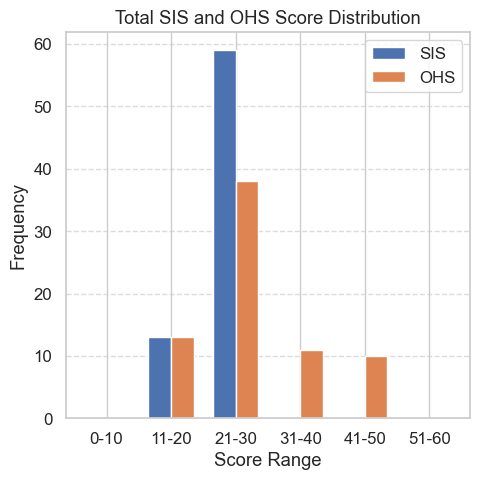

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
df = pd.read_csv("maison-llf-features.csv")

# Convert timestamps
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["clinical-timestamp"] = pd.to_datetime(df["clinical-timestamp"])

# Keep only rows where timestamp == clinical_timestamp
clinical_rows = df[df["timestamp"] == df["clinical-timestamp"]].copy()

# =========================================================
# SIS DISTRIBUTION
# =========================================================

sis_bins = [0, 10, 20, 30]
sis_labels = ["0-10", "11-20", "21-30"]

clinical_rows["sis_range"] = pd.cut(
    clinical_rows["sis"],
    bins=sis_bins,
    labels=sis_labels,
    include_lowest=True
)

sis_counts = clinical_rows["sis_range"].value_counts().sort_index()

# =========================================================
# OHS DISTRIBUTION
# =========================================================

ohs_bins = [0, 10, 20, 30, 40, 50, 60]
ohs_labels = ["0-10", "11-20", "21-30", "31-40", "41-50", "51-60"]

clinical_rows["ohs_range"] = pd.cut(
    clinical_rows["ohs"],
    bins=ohs_bins,
    labels=ohs_labels,
    include_lowest=True
)

ohs_counts = clinical_rows["ohs_range"].value_counts().sort_index()

# =========================================================
# COMBINED PLOT
# =========================================================

# Use all possible ranges on x-axis
all_ranges = ohs_labels

# Align SIS counts to same x-axis
sis_values = [sis_counts.get(label, 0) for label in all_ranges]
ohs_values = [ohs_counts.get(label, 0) for label in all_ranges]

x = np.arange(len(all_ranges))
width = 0.35

plt.figure(figsize=(5, 5))

# Plot bars
plt.bar(x - width/2, sis_values, width=width, label="SIS")
plt.bar(x + width/2, ohs_values, width=width, label="OHS")

# Labels and title
plt.xlabel("Score Range")
plt.ylabel("Frequency")
plt.title("Total SIS and OHS Score Distribution")

# X ticks
plt.xticks(x, all_ranges)

# Grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Legend
plt.legend()

plt.tight_layout()
plt.show()

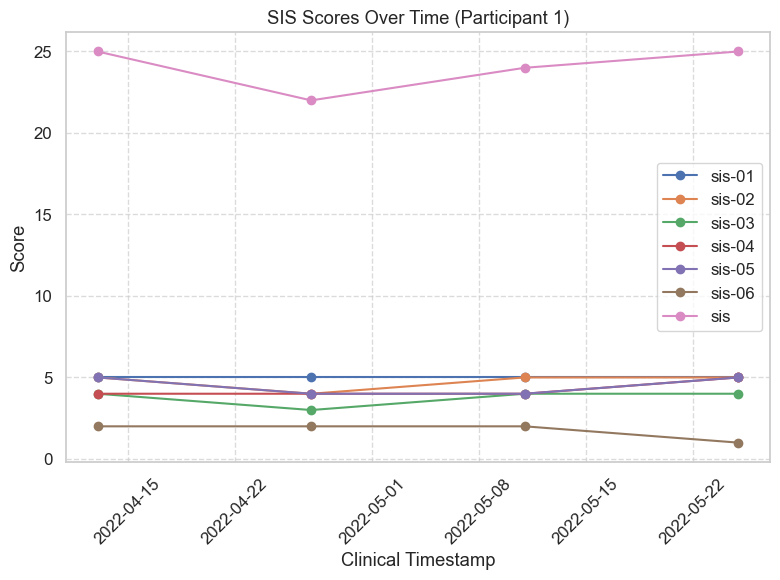

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("maison-llf-features.csv")

# Convert timestamps
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["clinical-timestamp"] = pd.to_datetime(df["clinical-timestamp"])

# =========================================================
# FILTER FIRST PARTICIPANT
# =========================================================

first_participant = df["participant"].unique()[0]

participant_df = df[
    (df["participant"] == first_participant) &
    (df["timestamp"] == df["clinical-timestamp"])
].copy()

# Sort by time
participant_df = participant_df.sort_values("timestamp")

# =========================================================
# SCORE COLUMNS
# =========================================================

score_columns = [
    "sis-01",
    "sis-02",
    "sis-03",
    "sis-04",
    "sis-05",
    "sis-06",
    "sis"
]

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(8, 6))

for col in score_columns:
    plt.plot(
        participant_df["timestamp"],
        participant_df[col],
        marker='o',
        linestyle='-',
        label=col
    )

# Labels and title
plt.xlabel("Clinical Timestamp")
plt.ylabel("Score")
plt.title(f"SIS Scores Over Time (Participant {first_participant})")

# Grid
plt.grid(True, linestyle='--', alpha=0.7)

# Legend
plt.legend()

# Rotate x-axis labels
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

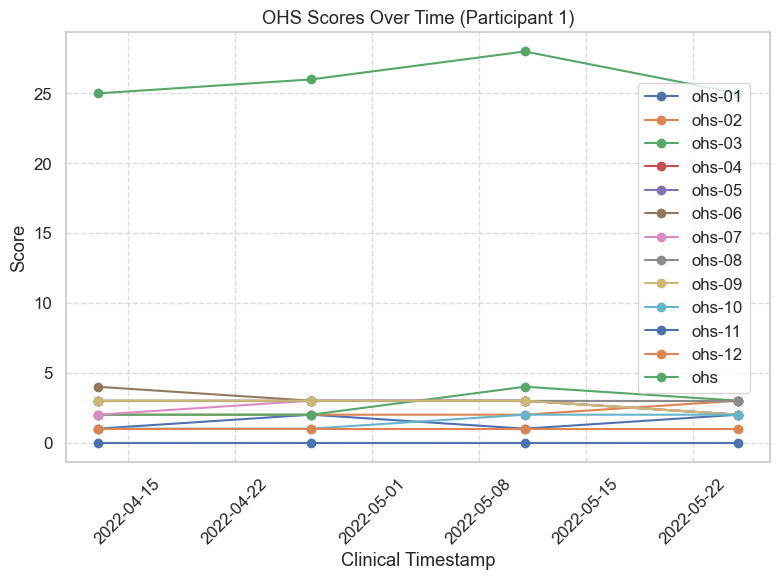

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("maison-llf-features.csv")

# Convert timestamps
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["clinical-timestamp"] = pd.to_datetime(df["clinical-timestamp"])

# =========================================================
# FILTER FIRST PARTICIPANT
# =========================================================

first_participant = df["participant"].unique()[0]

participant_df = df[
    (df["participant"] == first_participant) &
    (df["timestamp"] == df["clinical-timestamp"])
].copy()

# Sort by time
participant_df = participant_df.sort_values("timestamp")

# =========================================================
# SCORE COLUMNS
# =========================================================

score_columns = [
    "ohs-01",
    "ohs-02",
    "ohs-03",
    "ohs-04",
    "ohs-05",
    "ohs-06",
    "ohs-07",
    "ohs-08",
    "ohs-09",
    "ohs-10",
    "ohs-11",
    "ohs-12",
    "ohs"
]

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(8, 6))

for col in score_columns:
    plt.plot(
        participant_df["timestamp"],
        participant_df[col],
        marker='o',
        linestyle='-',
        label=col
    )

# Labels and title
plt.xlabel("Clinical Timestamp")
plt.ylabel("Score")
plt.title(f"OHS Scores Over Time (Participant {first_participant})")

# Grid
plt.grid(True, linestyle='--', alpha=0.7)

# Legend
plt.legend(bbox_to_anchor=(0.8, 0.9), loc='upper left')

# Rotate x-axis labels
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


================ SIS FEATURE IMPORTANCE ================

                                  feature  shap_importance
9          acceleration-minutes-with-data         0.905071
11    acceleration-movement-events-00to06         0.702581
37               sleep-duration-to-wakeup         0.177346
2                       acceleration-mean         0.165545
36                sleep-duration-to-sleep         0.146202
0                              chairstand         0.142386
41                    sleep-heartrate-max         0.119935
44                              step-mean         0.115657
7                       acceleration-skew         0.096894
6                   acceleration-kurtosis         0.094397
42                             step-count         0.093157
39                   sleep-heartrate-mean         0.088731
19                          heartrate-max         0.083440
24                           motion-ratio         0.074483
21                          heartrate-std         0.0741

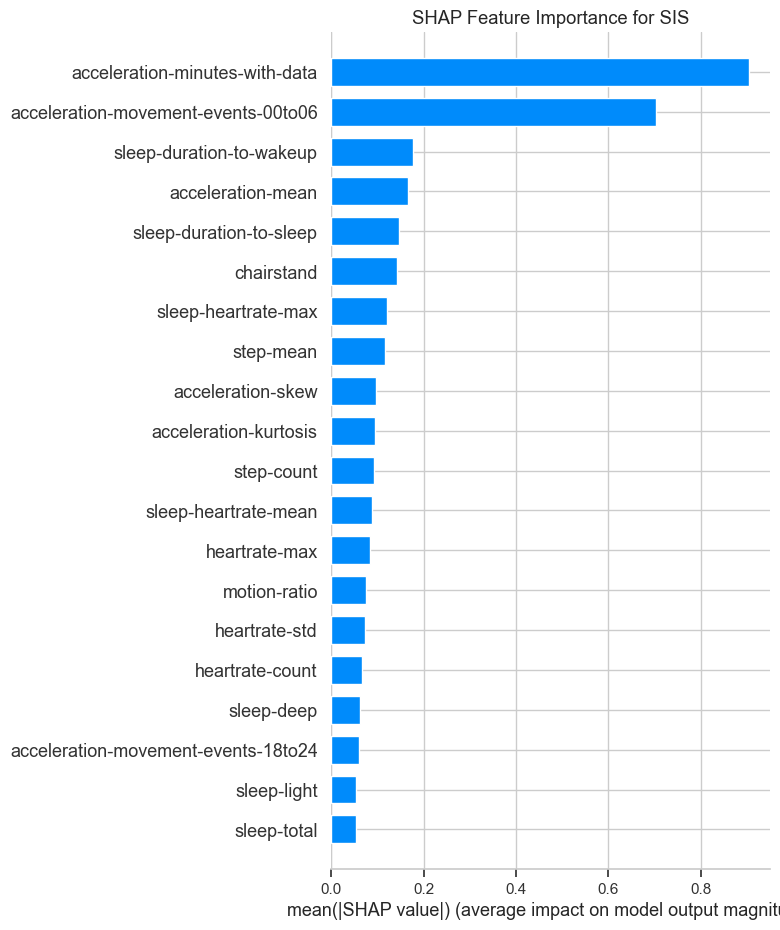

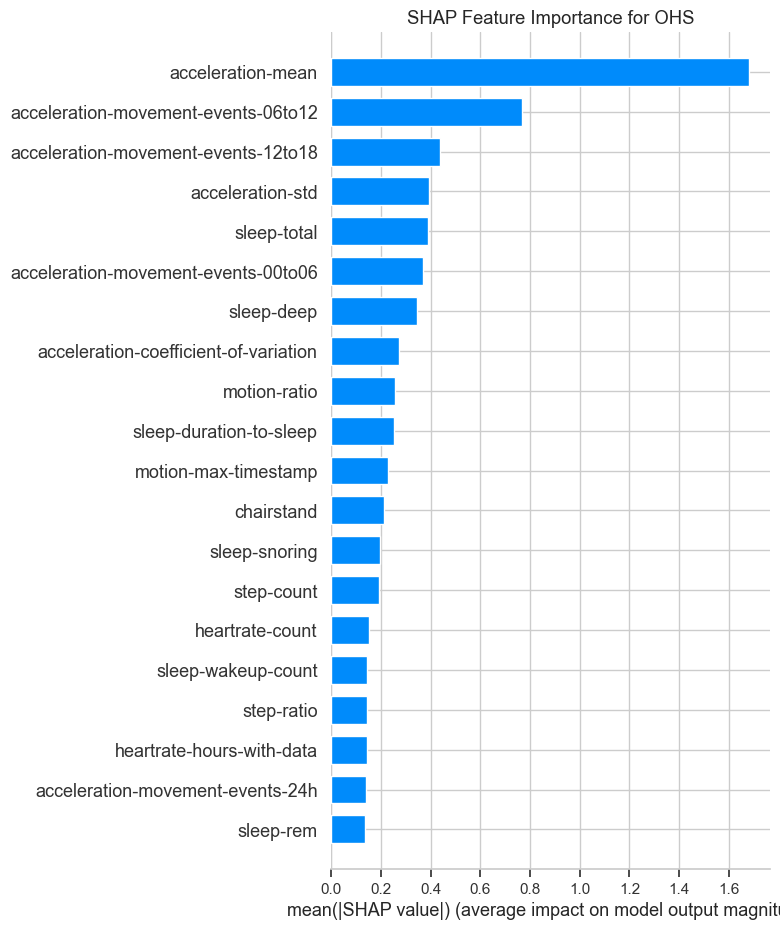

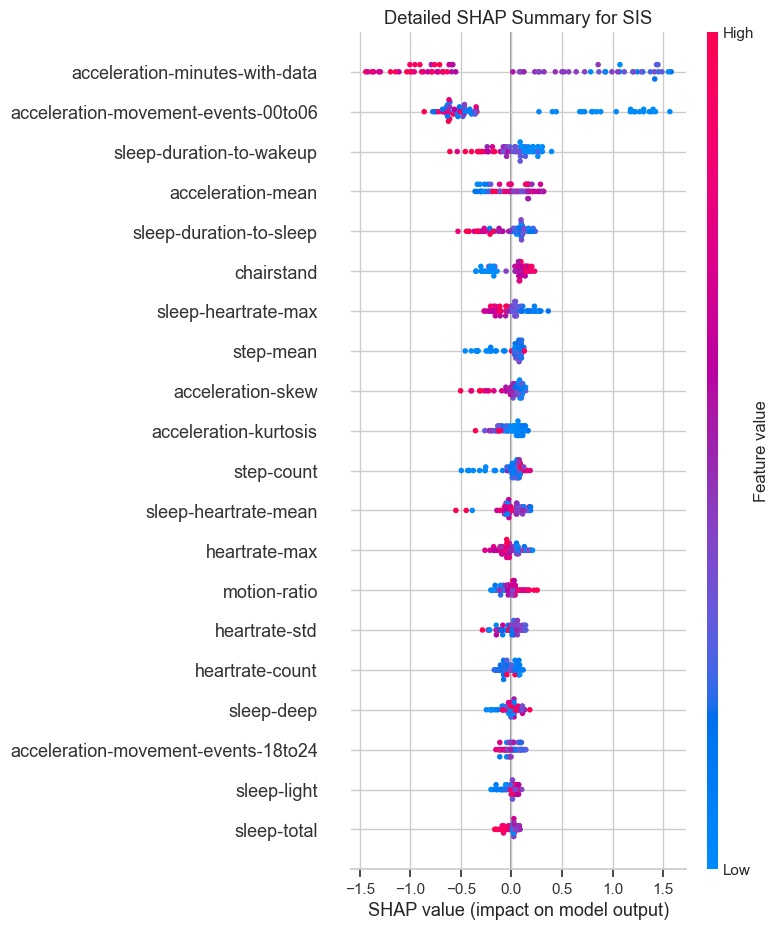

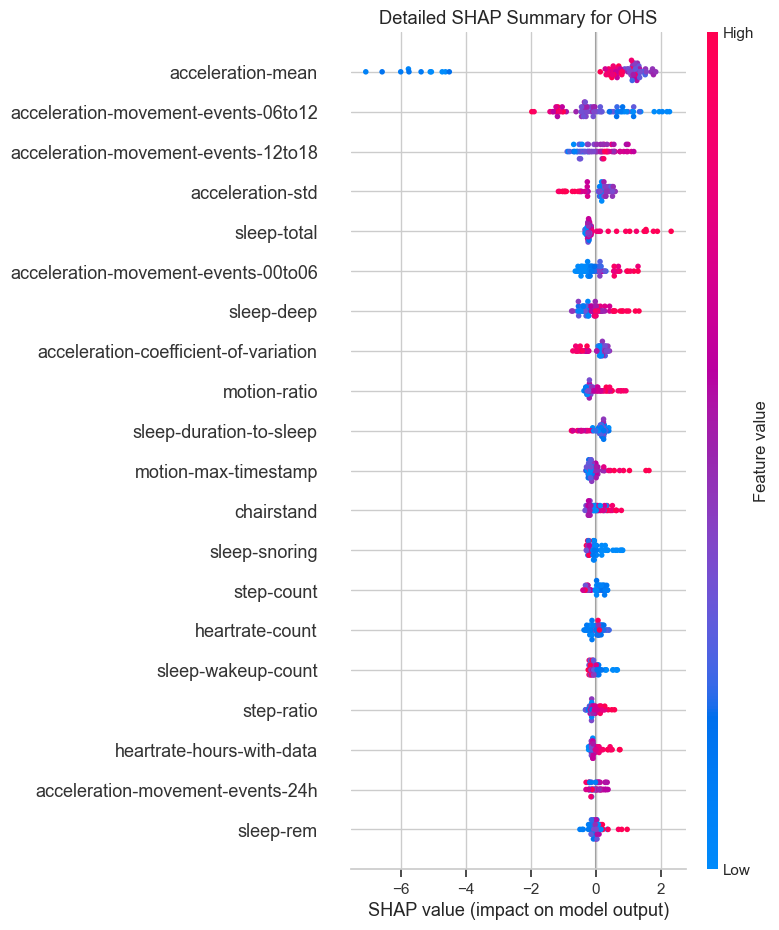


Saved:
- shap_sis_feature_importance.csv
- shap_ohs_feature_importance.csv


In [41]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv("maison-llf-features.csv")

# Convert timestamps
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["clinical-timestamp"] = pd.to_datetime(df["clinical-timestamp"])

# =========================================================
# KEEP ONLY CLINICAL TIMESTAMP ROWS
# =========================================================

df = df[df["timestamp"] == df["clinical-timestamp"]].copy()

# =========================================================
# REMOVE NON-FEATURE COLUMNS
# =========================================================

exclude_prefixes = ("sis", "ohs", "oks", "tug")

exclude_columns = [
    "timestamp",
    "clinical-timestamp",
    "participant"
]

feature_columns = [
    col for col in df.columns
    if (
        not col.startswith(exclude_prefixes)
        and col not in exclude_columns
    )
]

# =========================================================
# PREPARE FEATURES
# =========================================================

X = df[feature_columns]

# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

# Fill missing values
imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

# =========================================================
# TARGETS
# =========================================================

y_sis = df["sis"]
y_ohs = df["ohs"]

# =========================================================
# TRAIN MODELS
# =========================================================

sis_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

ohs_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

sis_model.fit(X_imputed, y_sis)
ohs_model.fit(X_imputed, y_ohs)

# =========================================================
# SHAP VALUES
# =========================================================

sis_explainer = shap.TreeExplainer(sis_model)
sis_shap_values = sis_explainer.shap_values(X_imputed)

ohs_explainer = shap.TreeExplainer(ohs_model)
ohs_shap_values = ohs_explainer.shap_values(X_imputed)

# =========================================================
# COMPUTE FEATURE IMPORTANCE
# =========================================================

sis_importance = pd.DataFrame({
    "feature": X_imputed.columns,
    "shap_importance": np.abs(sis_shap_values).mean(axis=0)
}).sort_values(
    by="shap_importance",
    ascending=False
)

ohs_importance = pd.DataFrame({
    "feature": X_imputed.columns,
    "shap_importance": np.abs(ohs_shap_values).mean(axis=0)
}).sort_values(
    by="shap_importance",
    ascending=False
)

# =========================================================
# PRINT SHAP SCORES
# =========================================================

print("\n================ SIS FEATURE IMPORTANCE ================\n")
print(sis_importance)

print("\n================ OHS FEATURE IMPORTANCE ================\n")
print(ohs_importance)

# =========================================================
# SHAP BAR GRAPH - SIS
# =========================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    sis_shap_values,
    X_imputed,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance for SIS")
plt.tight_layout()
plt.show()

# =========================================================
# SHAP BAR GRAPH - OHS
# =========================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    ohs_shap_values,
    X_imputed,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance for OHS")
plt.tight_layout()
plt.show()

# =========================================================
# DETAILED SHAP BEESWARM GRAPH - SIS
# =========================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    sis_shap_values,
    X_imputed,
    show=False
)

plt.title("Detailed SHAP Summary for SIS")
plt.tight_layout()
plt.show()

# =========================================================
# DETAILED SHAP BEESWARM GRAPH - OHS
# =========================================================

plt.figure(figsize=(12, 8))

shap.summary_plot(
    ohs_shap_values,
    X_imputed,
    show=False
)

plt.title("Detailed SHAP Summary for OHS")
plt.tight_layout()
plt.show()

# =========================================================
# SAVE IMPORTANCE TABLES
# =========================================================

sis_importance.to_csv(
    "shap_sis_feature_importance.csv",
    index=False
)

ohs_importance.to_csv(
    "shap_ohs_feature_importance.csv",
    index=False
)

print("\nSaved:")
print("- shap_sis_feature_importance.csv")
print("- shap_ohs_feature_importance.csv")

## Inspect DataFrame Structure and Data Types
Show the first rows, data types, and basic structure of both datasets.

In [11]:
print("--- Demographics head ---")
print(demographics.head().to_string(index=False))
print("\n--- Demographics dtypes ---")
print(demographics.dtypes)
print("\n--- Features head ---")
print(features.head().to_string(index=False))
print("\n--- Features dtypes ---")
print(features.dtypes)

--- Demographics head ---
 participant    sex  age   fracture-type relationship            education               work ethnicity
           1 female   74    hip fracture      widowed undergraduate degree            retired     black
           2 female   66    hip fracture    separated undergraduate degree employed part-time caucasian
           3 female   70 pelvis fracture       single  secondary education            retired caucasian
           4 female   60  femur fracture     divorced  secondary education            retired caucasian
           5   male   75 hip replacement       single     doctorate degree employed part-time caucasian

--- Demographics dtypes ---
participant      int64
sex                str
age              int64
fracture-type      str
relationship       str
education          str
work               str
ethnicity          str
dtype: object

--- Features head ---
 participant  timestamp clinical-timestamp  sis-01  sis-02  sis-03  sis-04  sis-05  sis-06  sis  ohs

## Correlation Matrix and Heatmap
Compute correlations for numeric variables in the features dataset and display a heatmap.

Numeric feature columns: 82


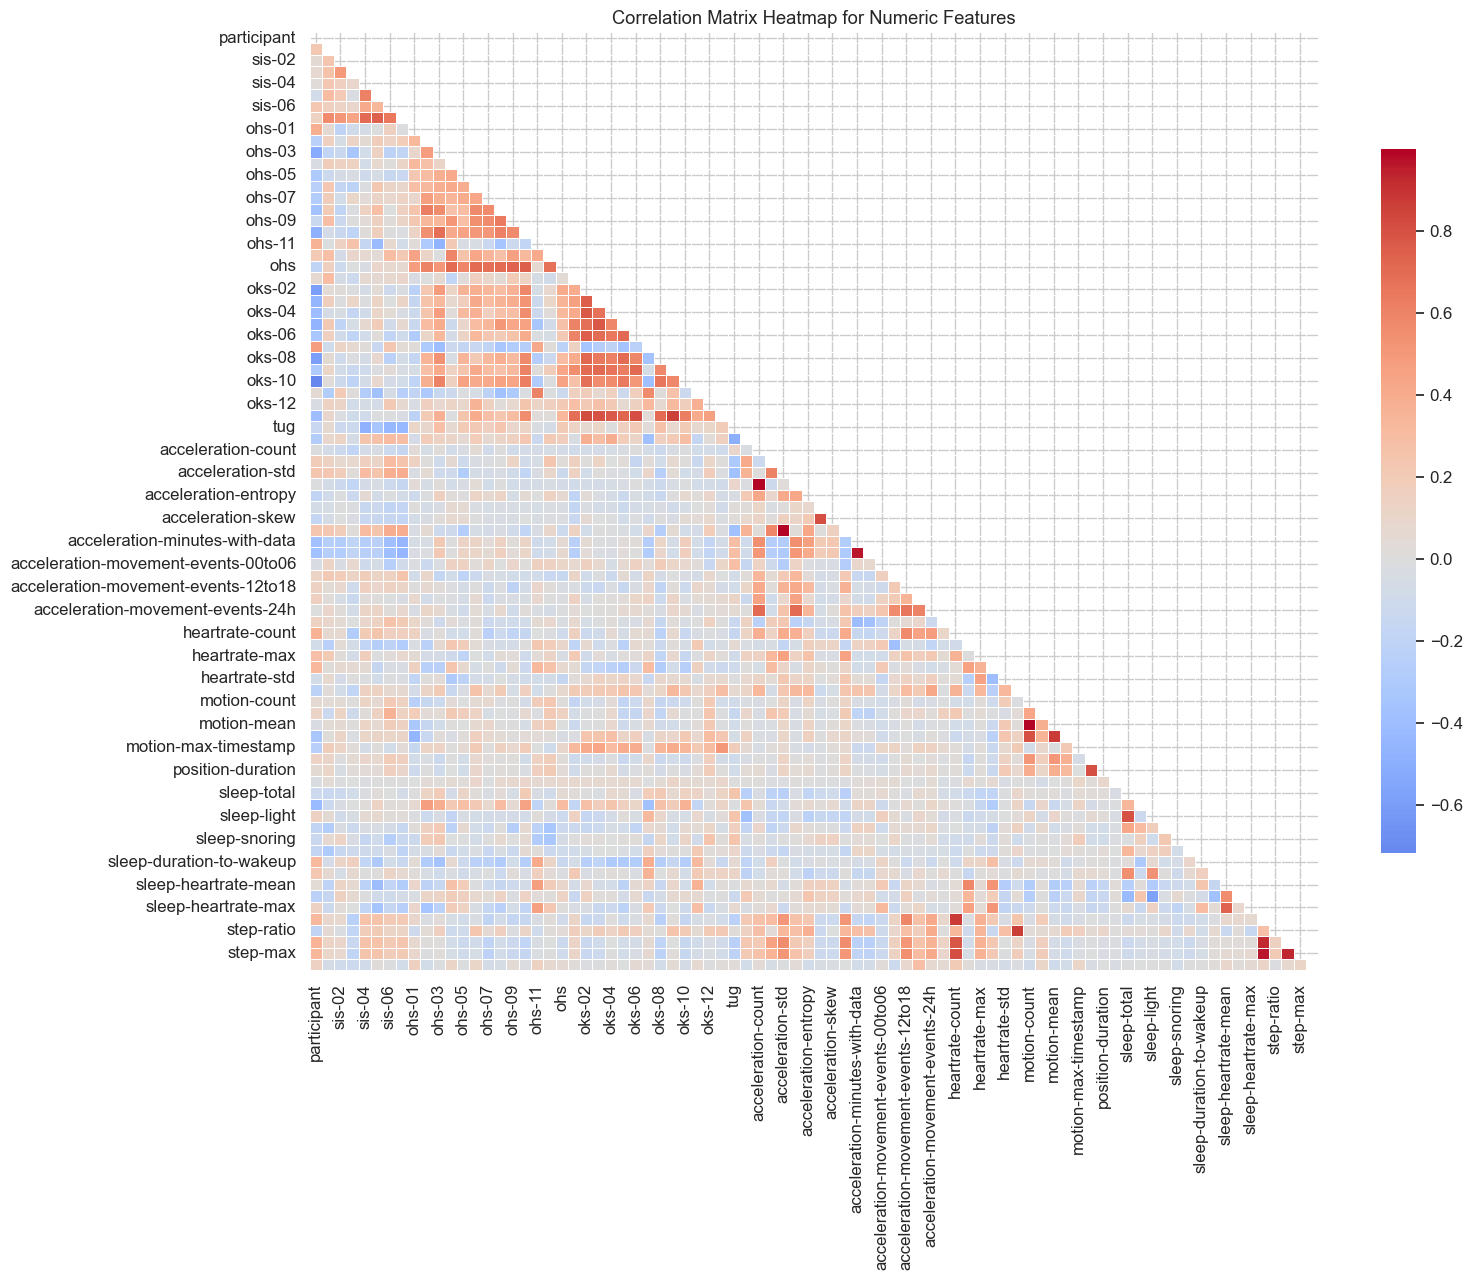

In [12]:
# Select numeric columns from features
numeric_features = features.select_dtypes(include=["number"])
print(f"Numeric feature columns: {numeric_features.shape[1]}")

# Compute correlation matrix
corr_matrix = numeric_features.corr()

# Plot heatmap for the numeric feature correlations
plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0, linewidths=0.5,
            cbar_kws={"shrink": 0.75}, fmt=".2f")
plt.title("Correlation Matrix Heatmap for Numeric Features")
plt.tight_layout()
plt.show()

## Missing Values and Percentage Missing
Calculate the count and percentage of missing values in each column for both datasets.

In [13]:
for name, df in [("Demographics", demographics), ("Features", features)]:
    missing_count = df.isna().sum()
    missing_pct = df.isna().mean() * 100
    missing_summary = pd.DataFrame({
        "missing_count": missing_count,
        "missing_pct": missing_pct
    })
    missing_summary = missing_summary[missing_summary["missing_count"] > 0]
    print(f"--- {name} missing values ---")
    if missing_summary.empty:
        print("No missing values detected.")
    else:
        display(missing_summary.sort_values(by="missing_pct", ascending=False))
    print("\n")

--- Demographics missing values ---
No missing values detected.


--- Features missing values ---
No missing values detected.




## Histogram for Numeric Variable Distribution
Visualize the distribution of a representative numeric variable from the demographics dataset.

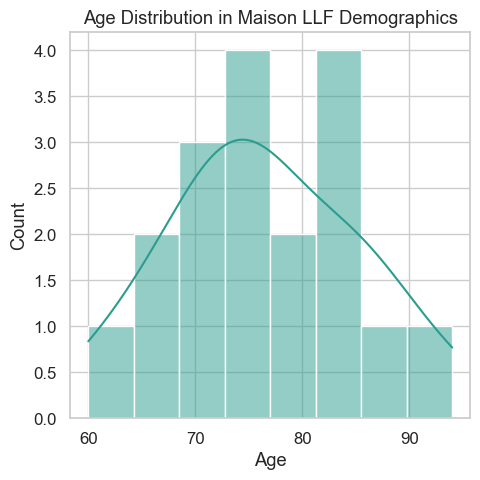

In [42]:
plt.figure(figsize=(5, 5))
sns.histplot(demographics["age"], kde=True, bins=8, color="#2a9d8f")
plt.title("Age Distribution in Maison LLF Demographics")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Compare Categorical Group Means with a Boxplot
Use `sex` as the categorical grouping variable and compare the distribution of `age` across groups.

/var/folders/3s/c_rstm216ld5ms719wdw9_9c0000gn/T/ipykernel_86921/3176747022.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=demographics, x="sex", y="age", palette="Set2")


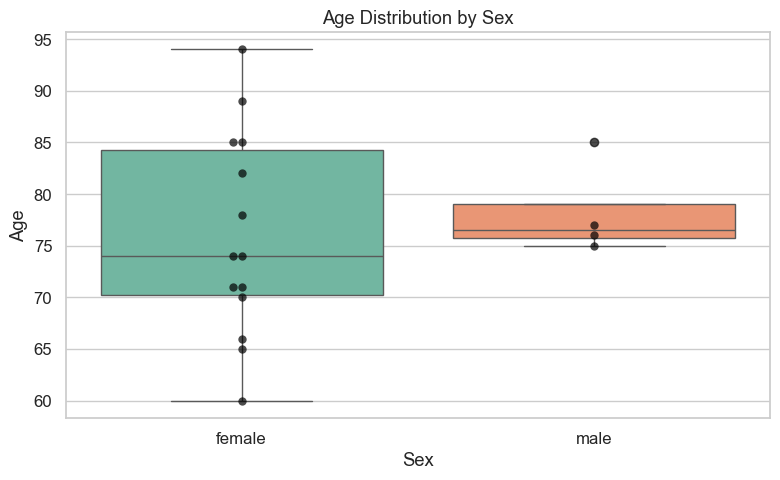

Group means by sex:
sex
female    76.00
male      78.25
Name: age, dtype: float64


In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=demographics, x="sex", y="age", palette="Set2")
sns.swarmplot(data=demographics, x="sex", y="age", color="black", size=6, alpha=0.7)
plt.title("Age Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

print("Group means by sex:")
print(demographics.groupby("sex")["age"].mean().round(2))

## Patient-level SIS, OHS, and OKS Trend Plots
Plot patient-specific clinical assessment trajectories for SIS, OHS, and OKS items across assessment timestamps.


Patient 1: 1 rows = 56


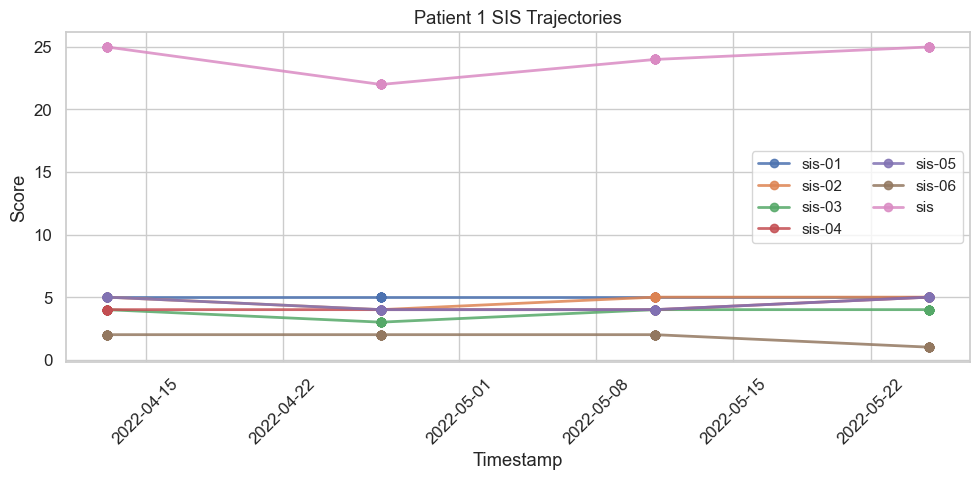

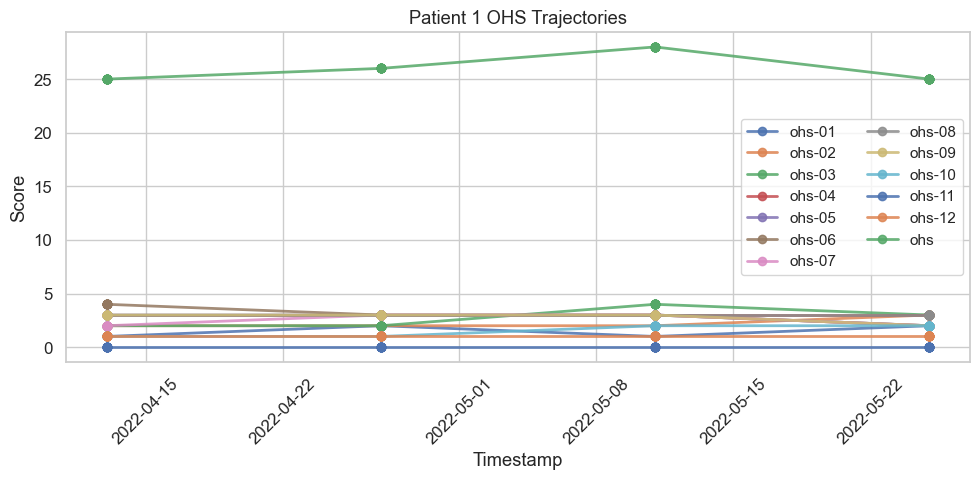

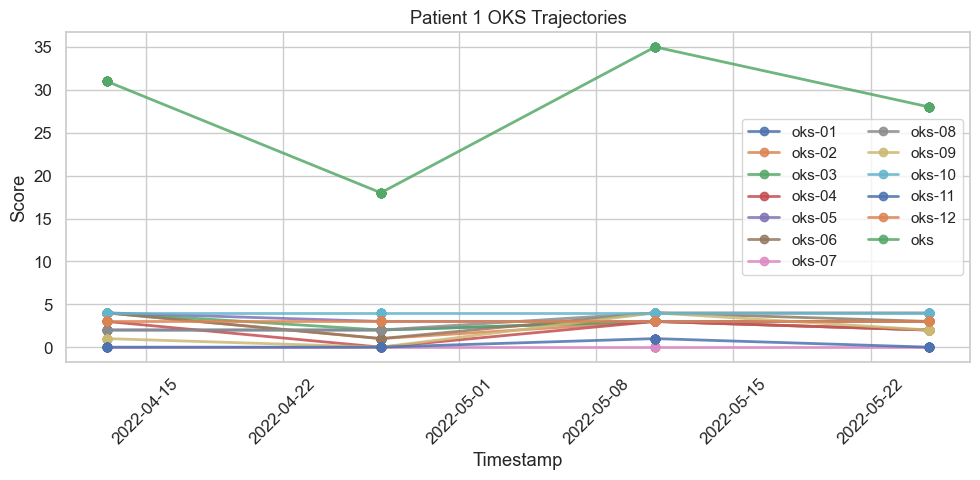


Patient 2: 2 rows = 56


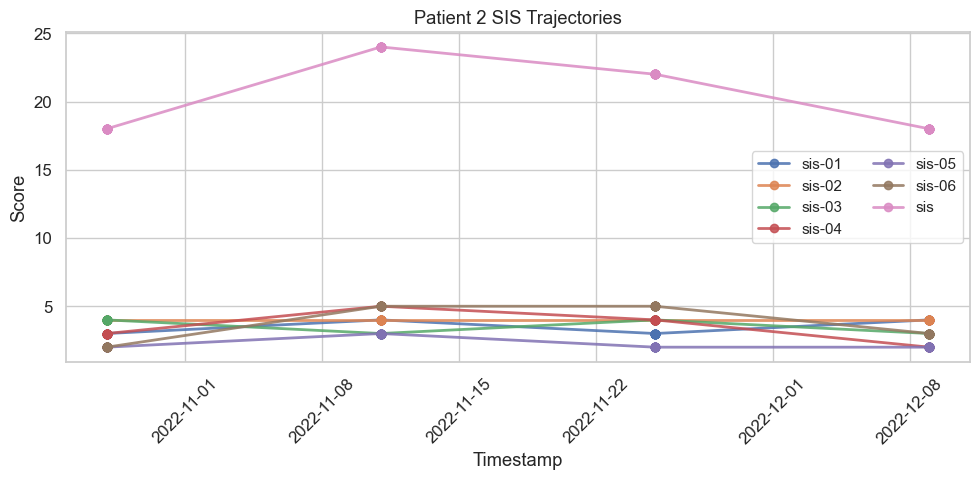

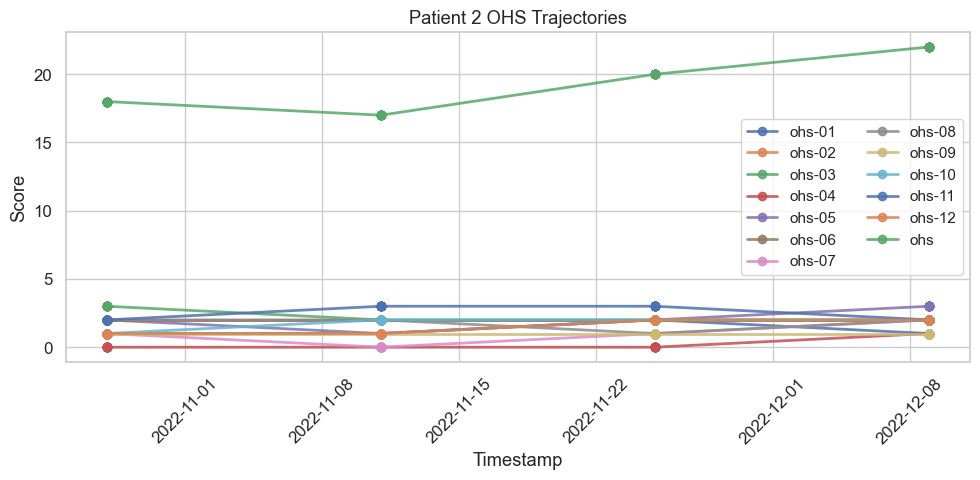

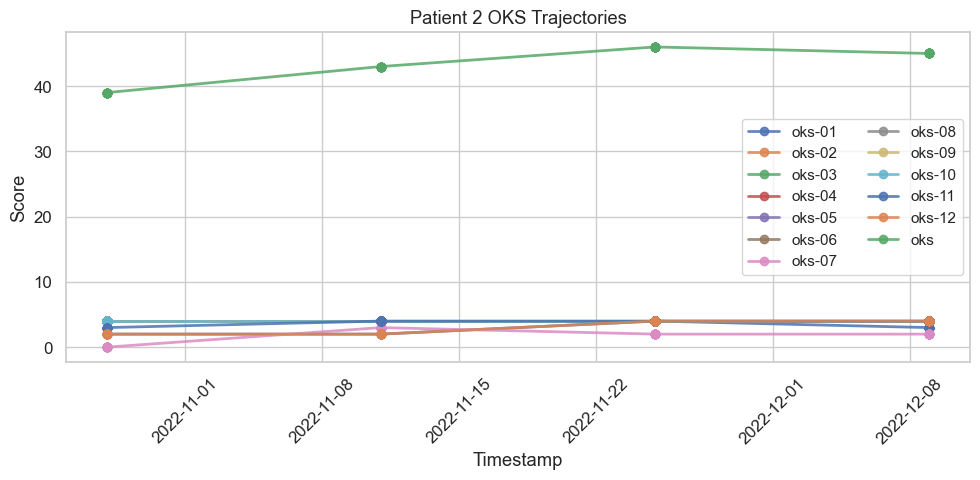


Patient 3: 3 rows = 56


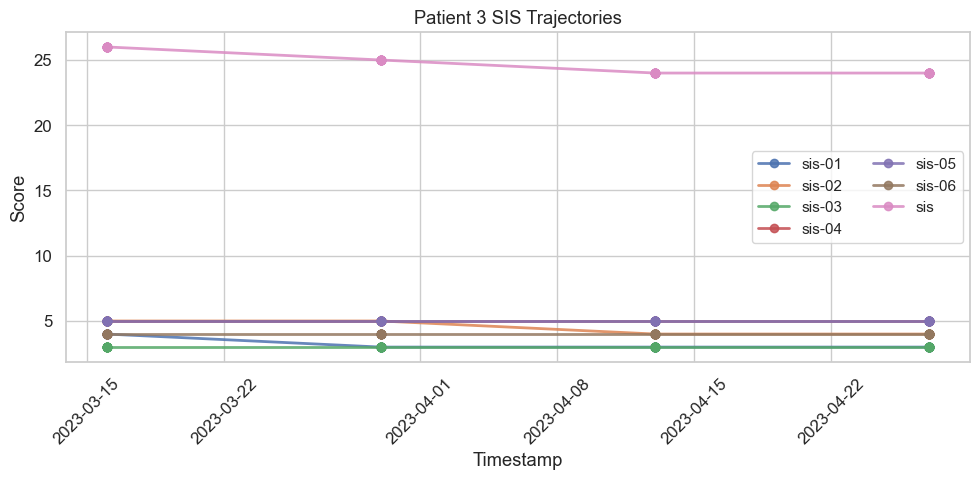

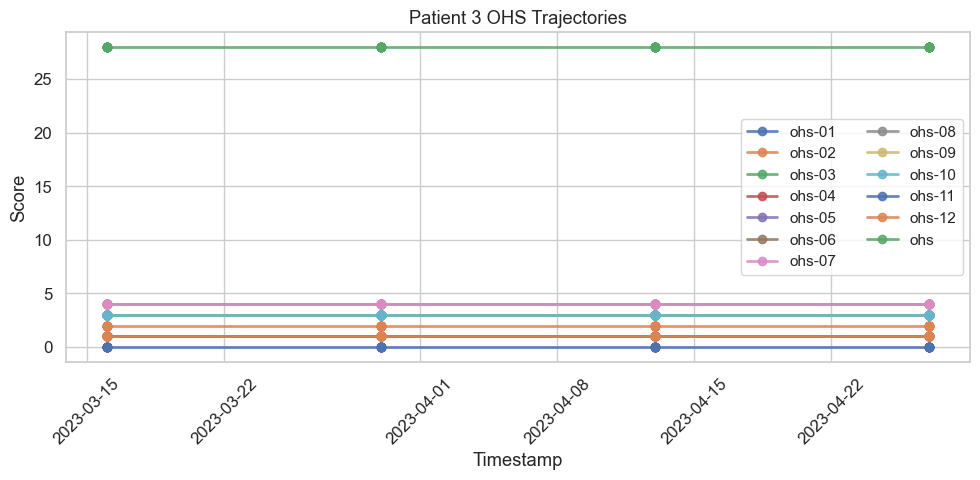

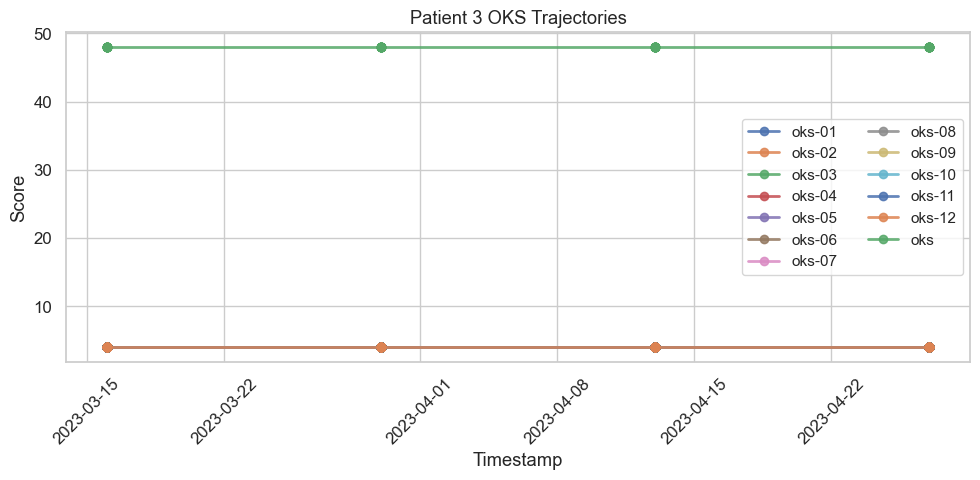


Patient 4: 4 rows = 56


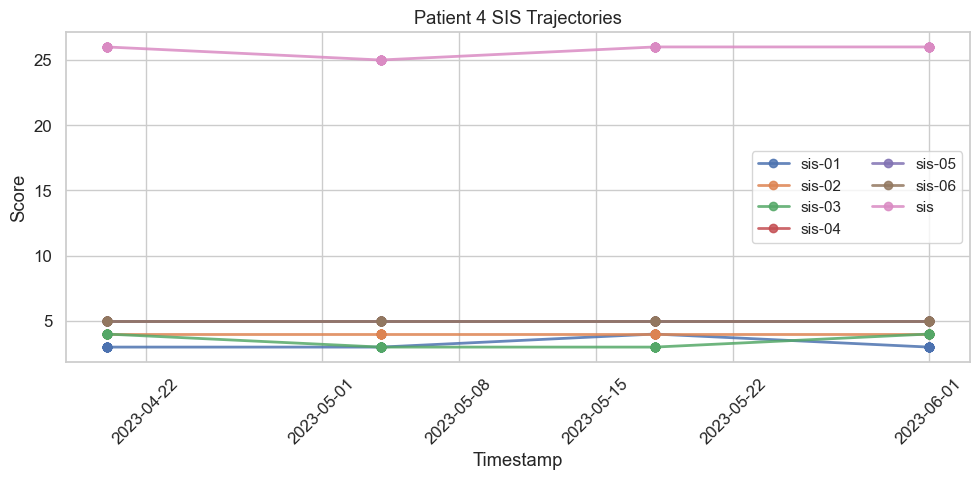

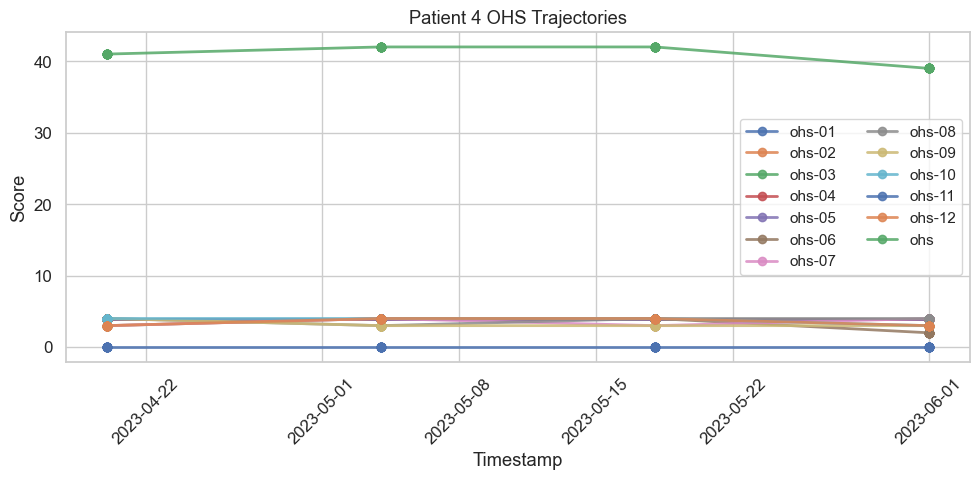

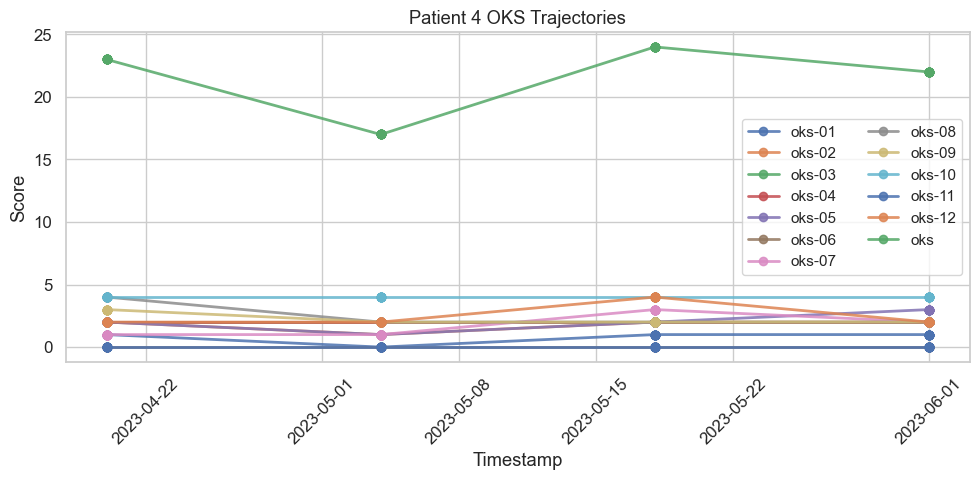


Patient 5: 5 rows = 56


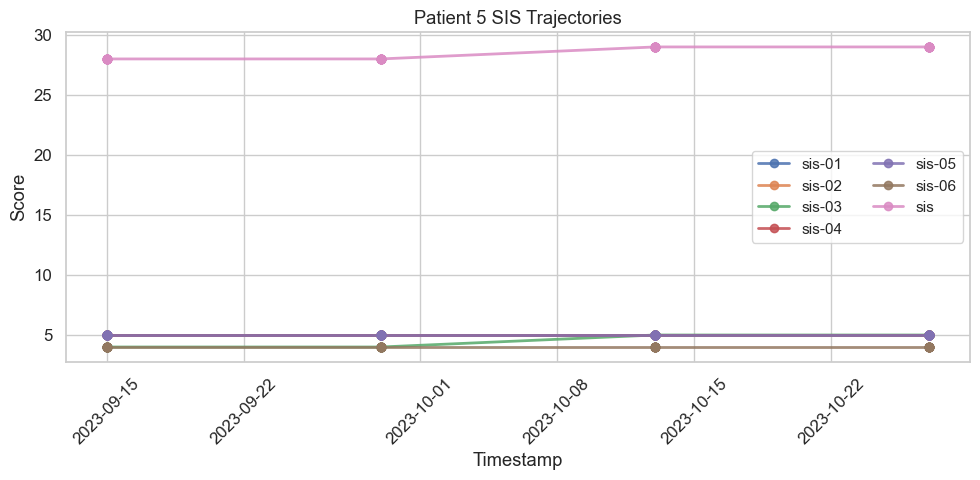

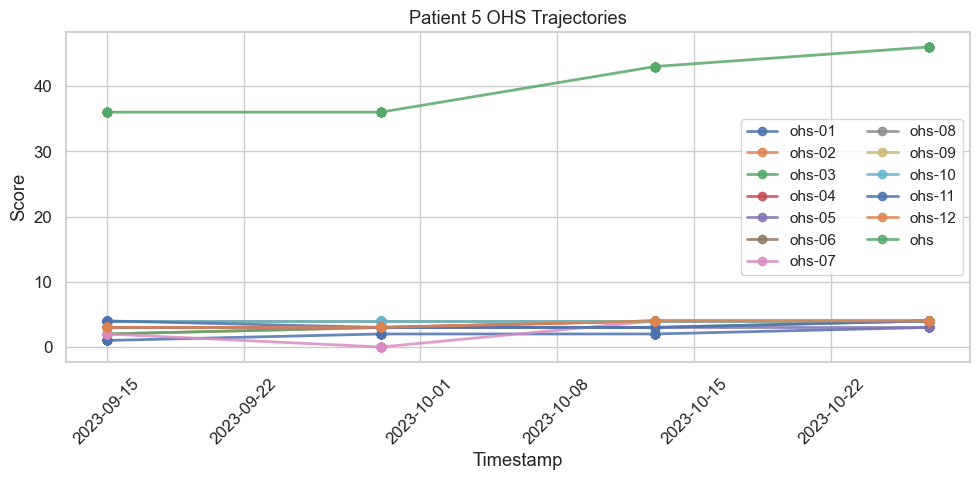

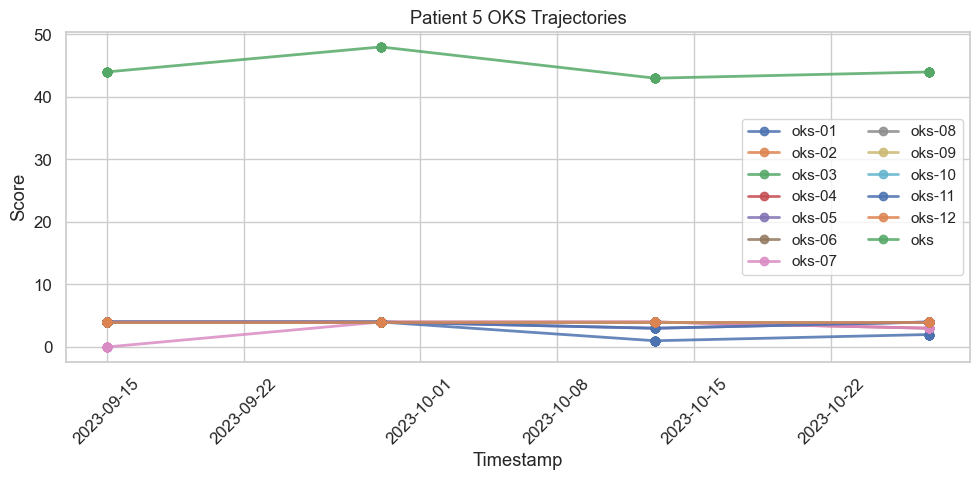


Patient 6: 6 rows = 56


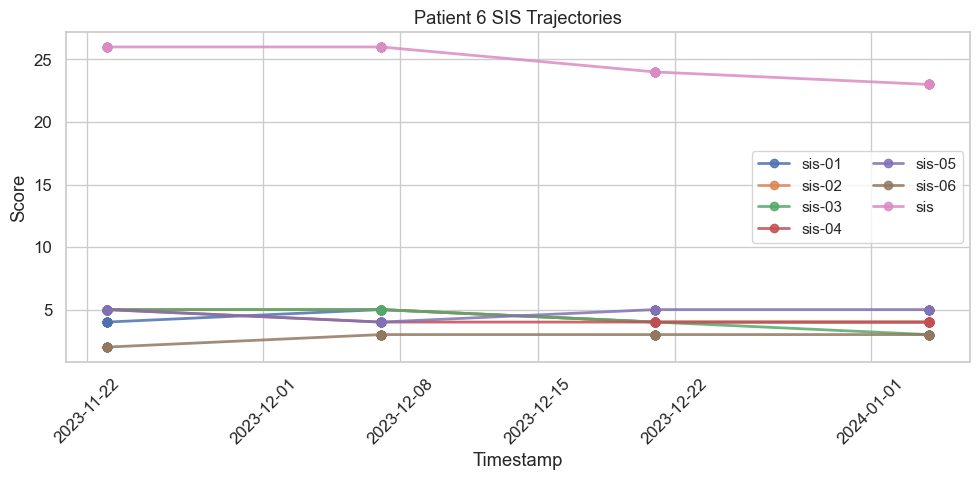

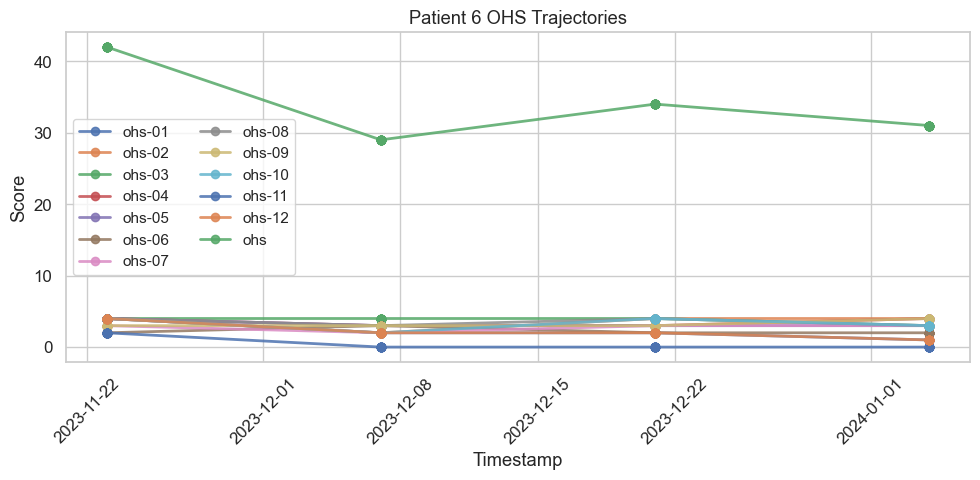

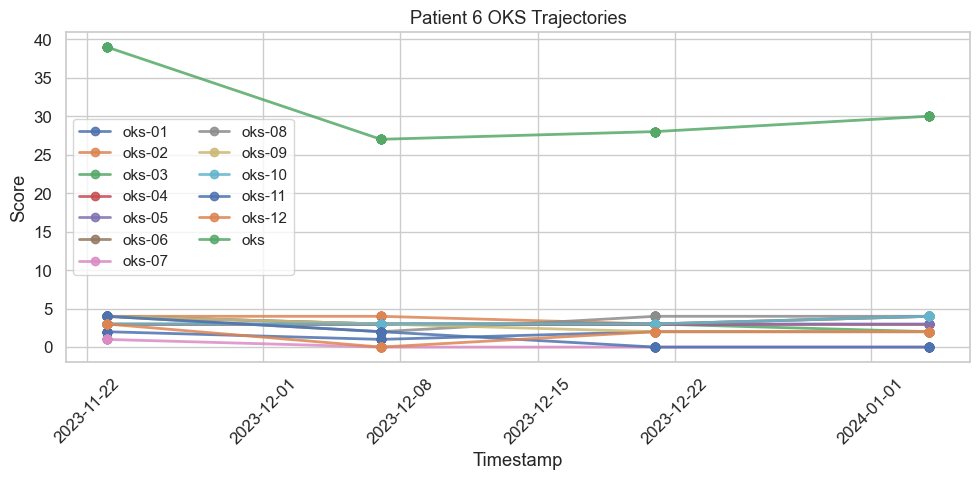


Patient 7: 7 rows = 56


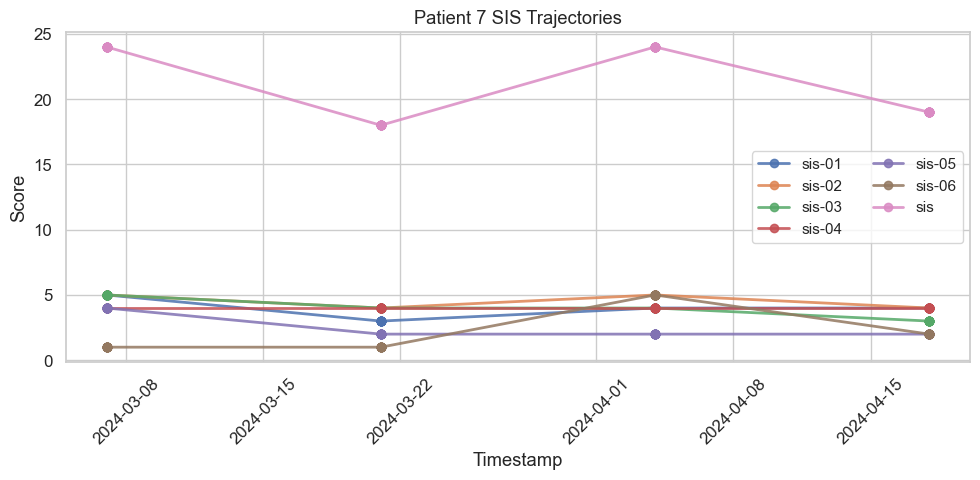

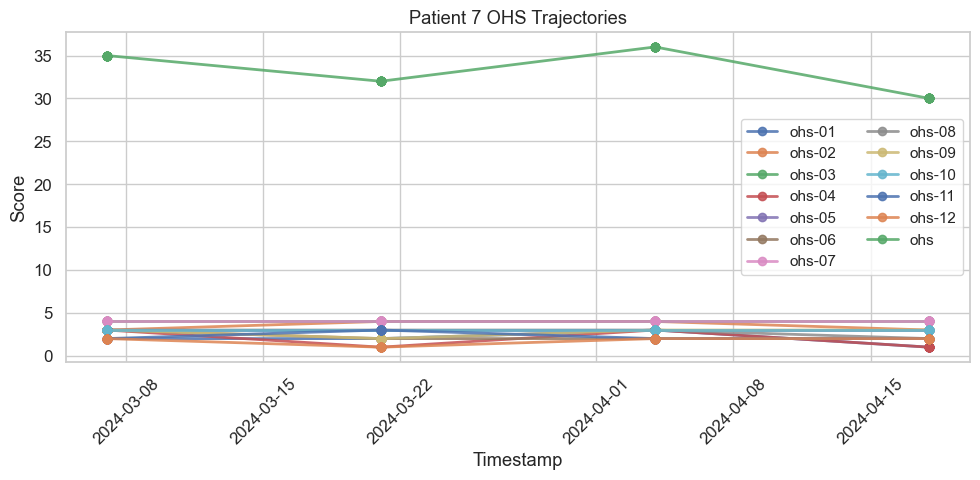

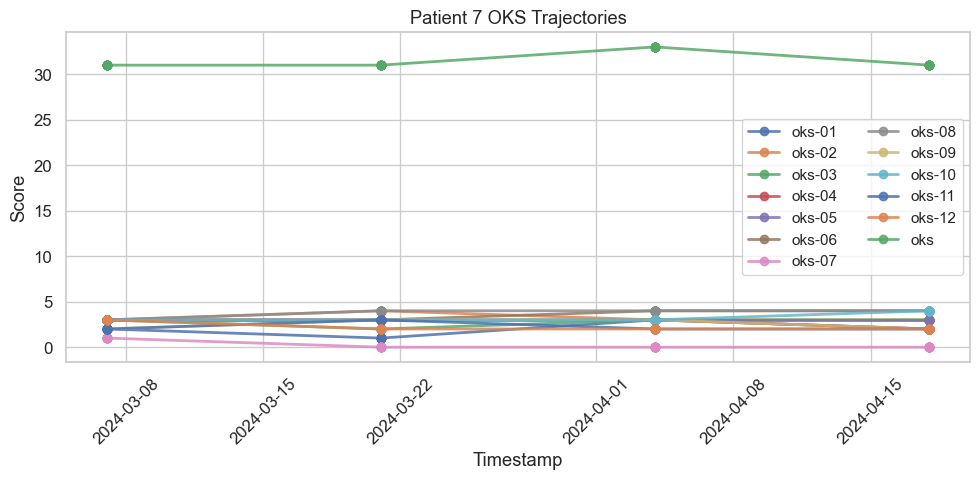


Patient 8: 8 rows = 56


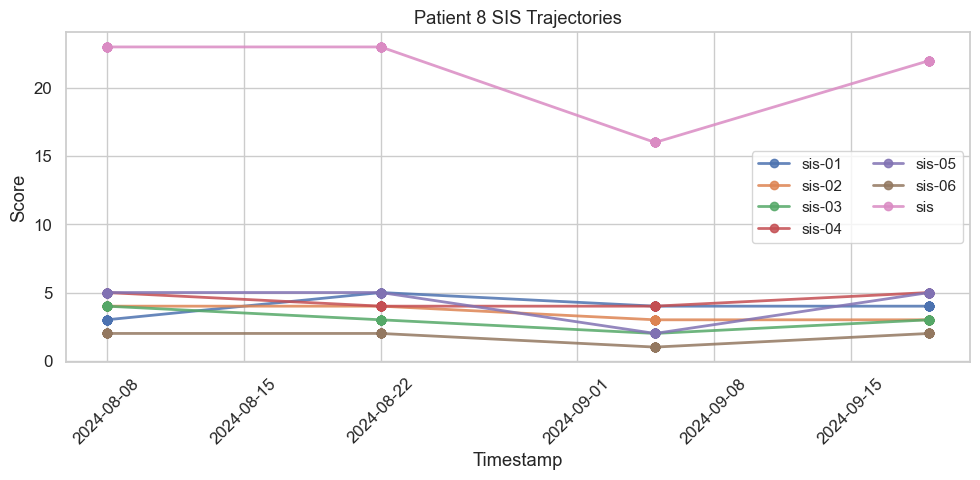

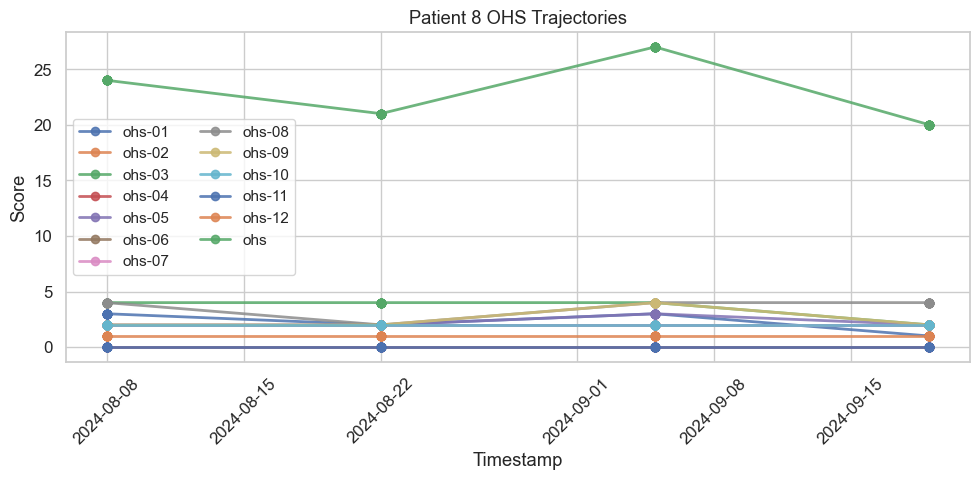

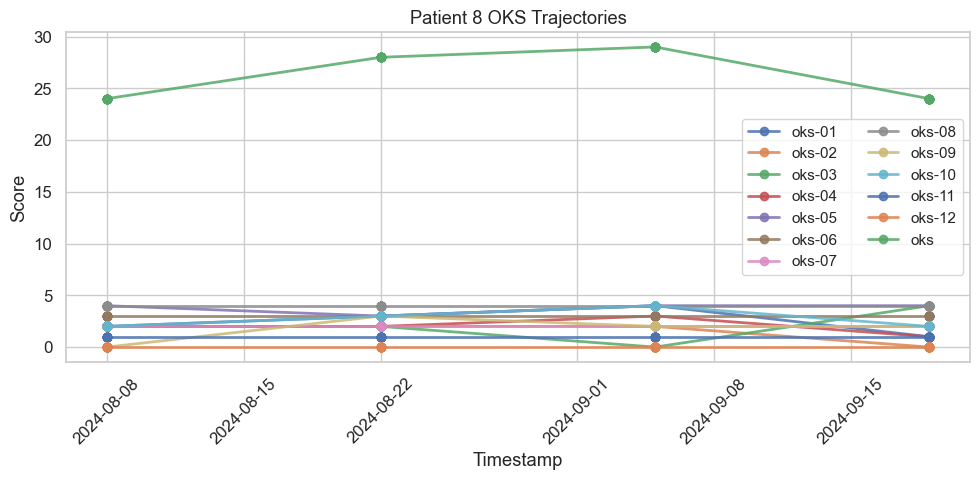


Patient 9: 9 rows = 56


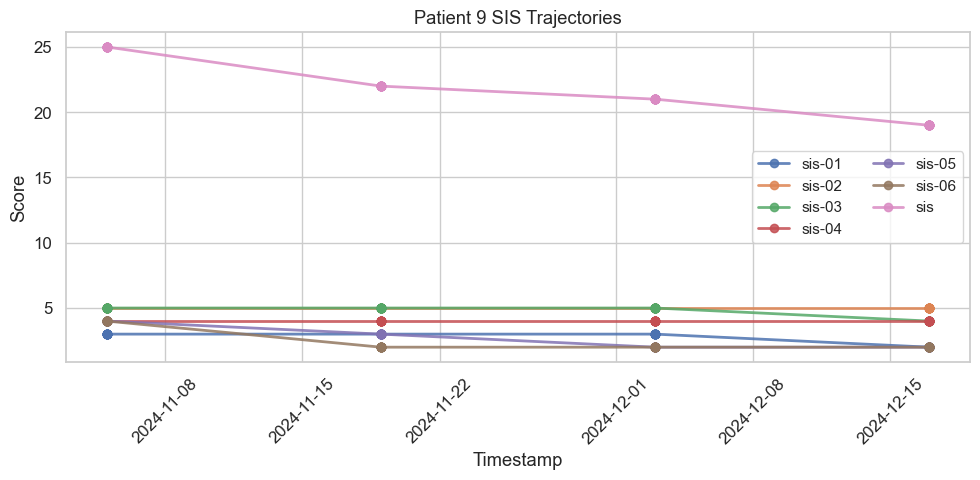

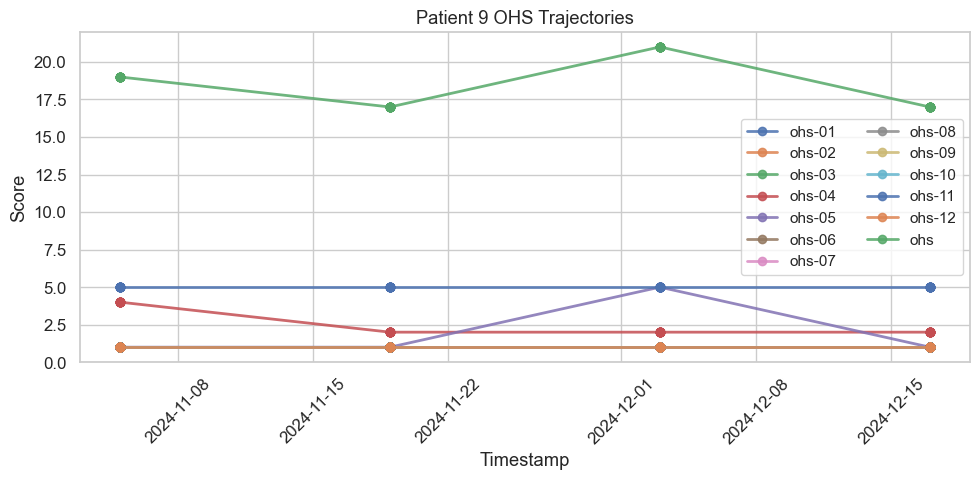

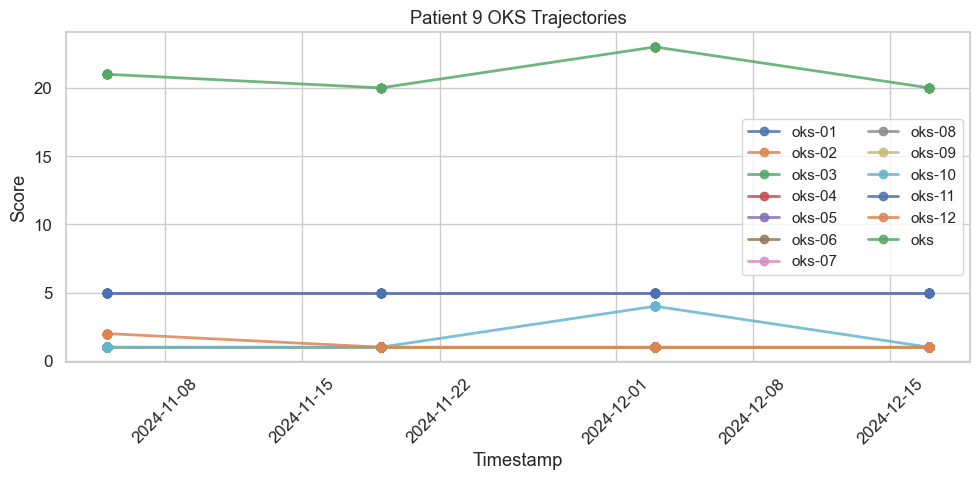


Patient 10: 10 rows = 56


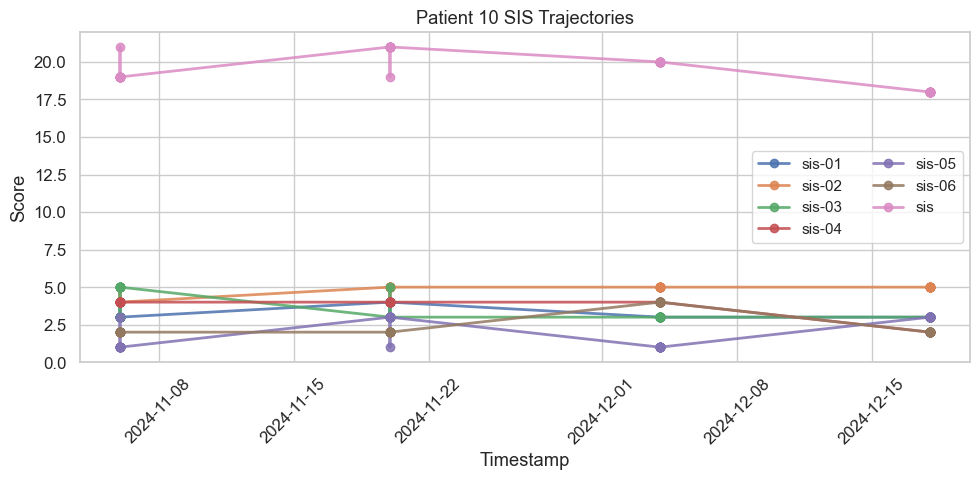

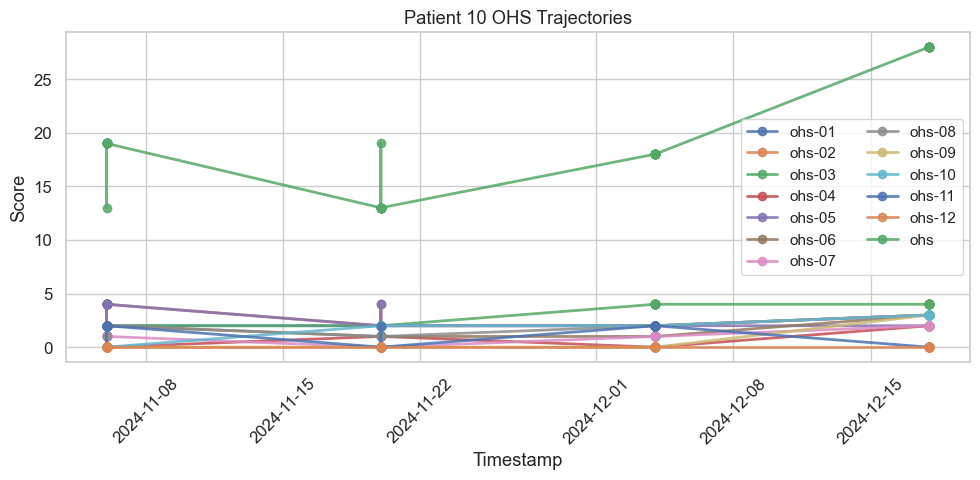

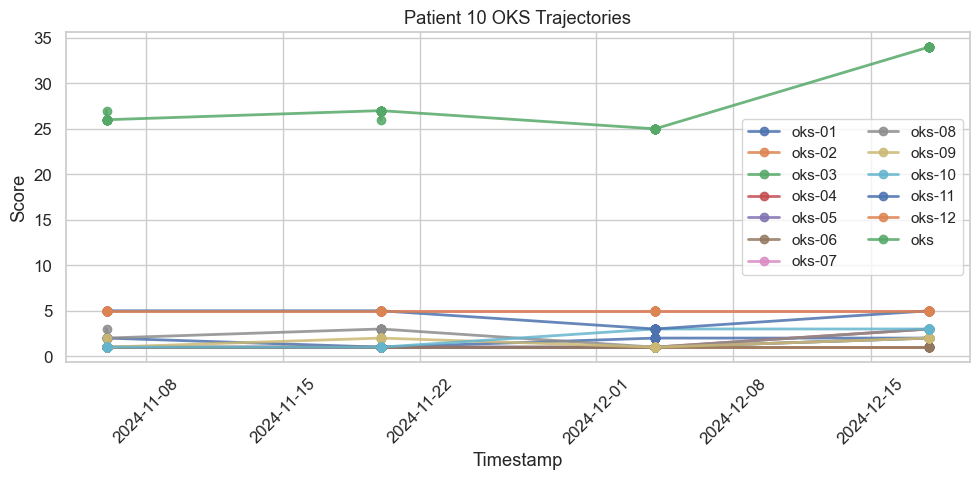


Patient 11: 11 rows = 56


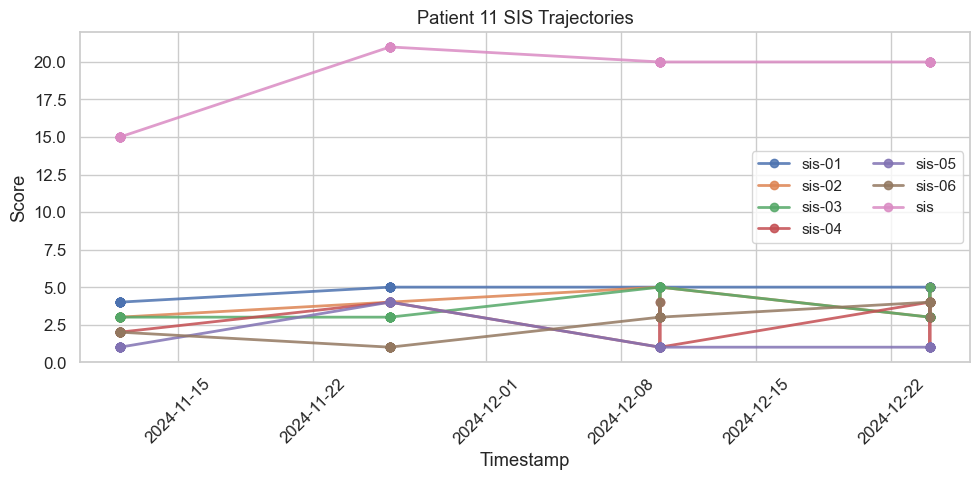

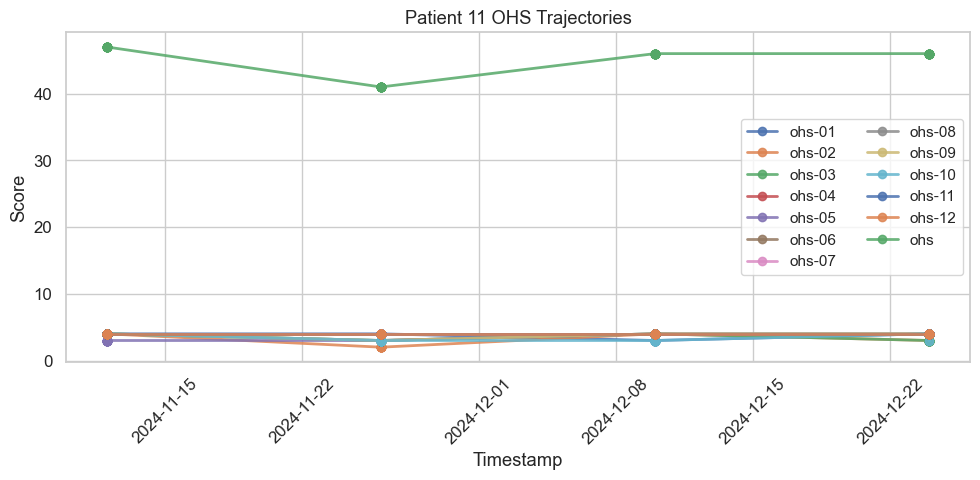

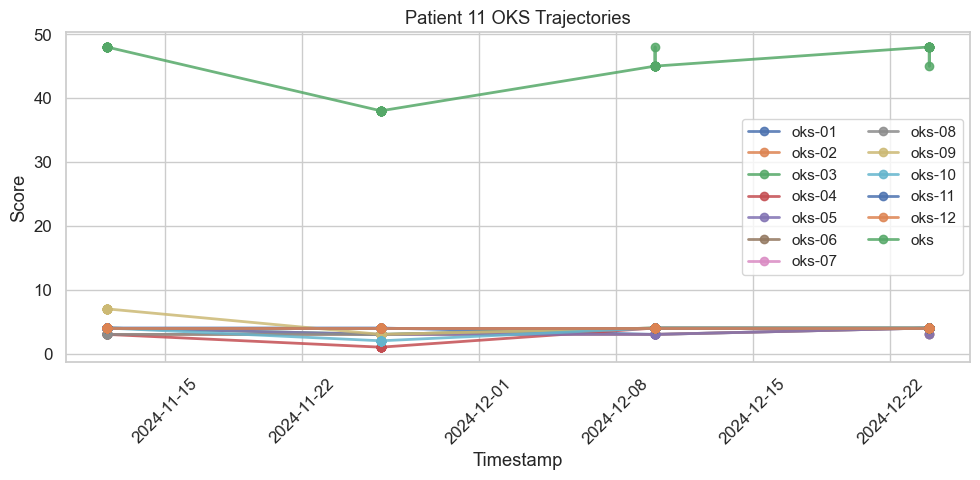


Patient 12: 12 rows = 56


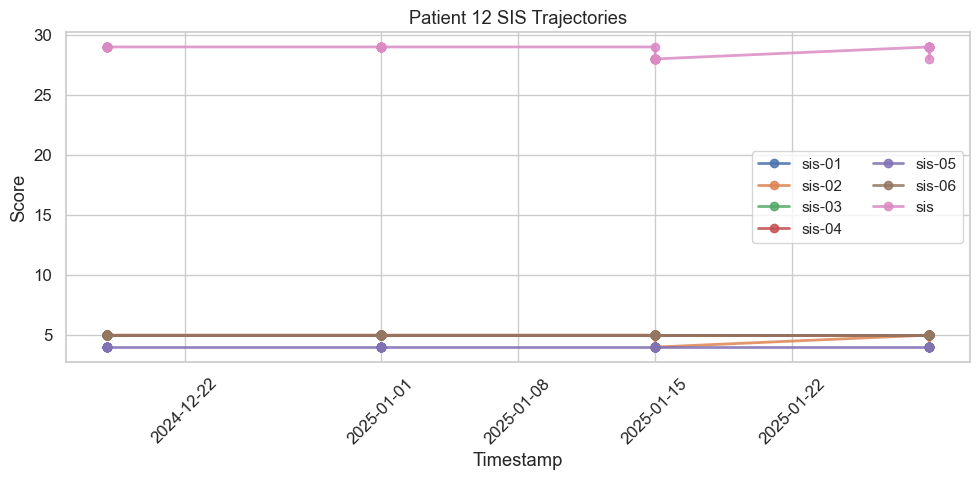

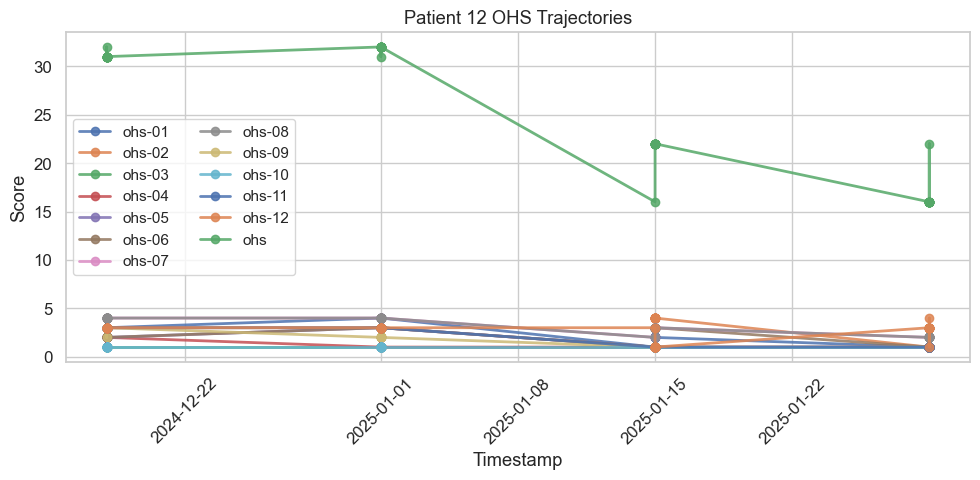

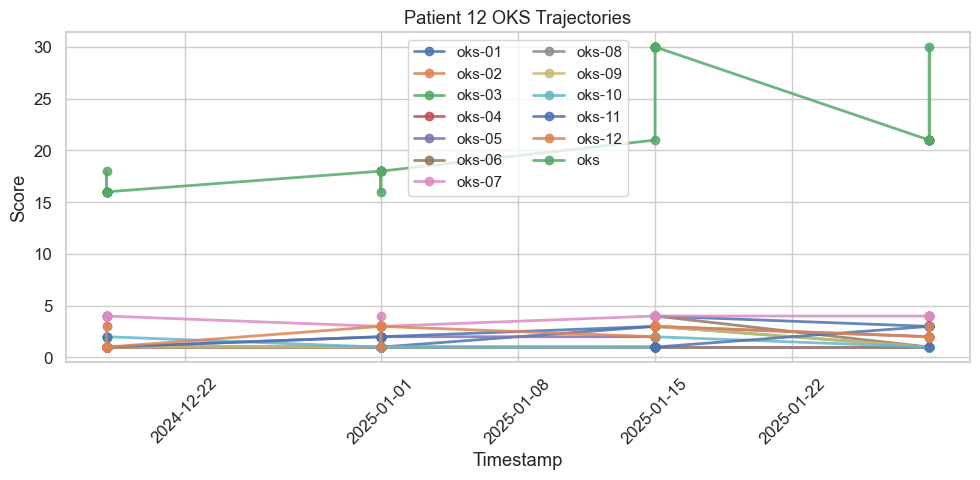


Patient 13: 13 rows = 56


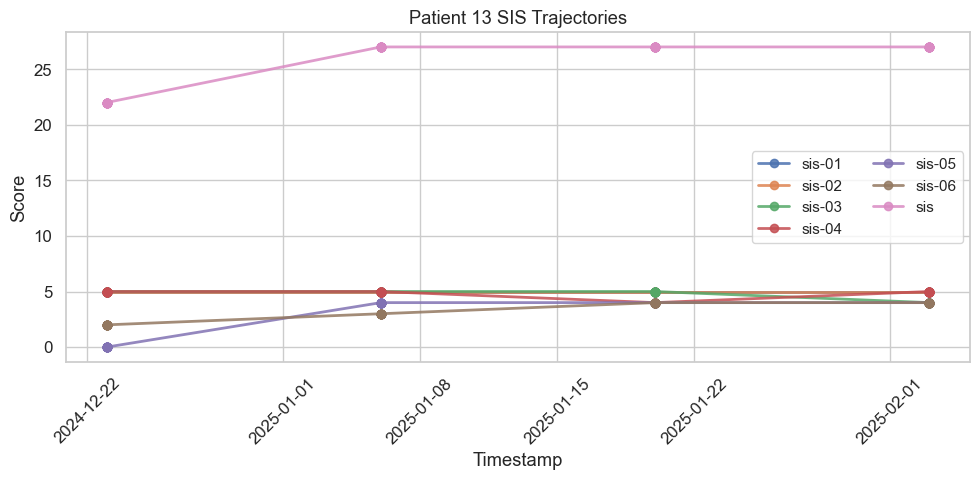

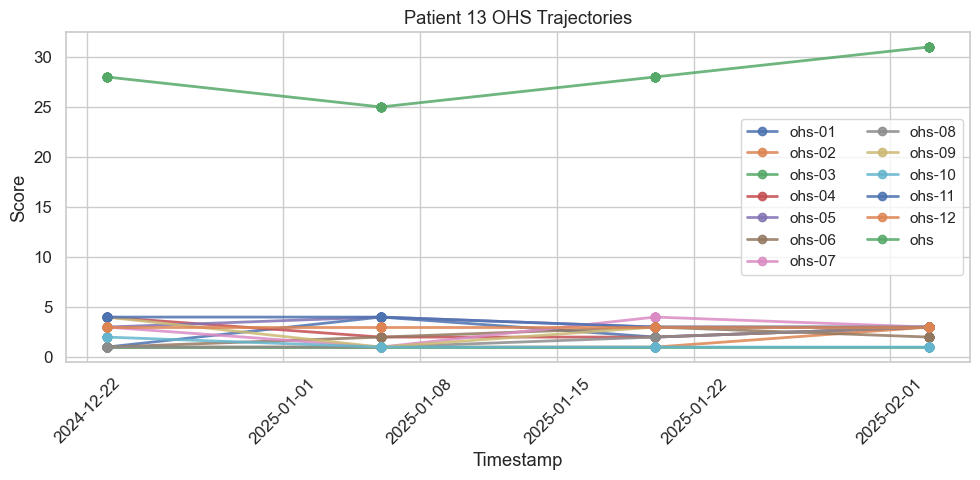

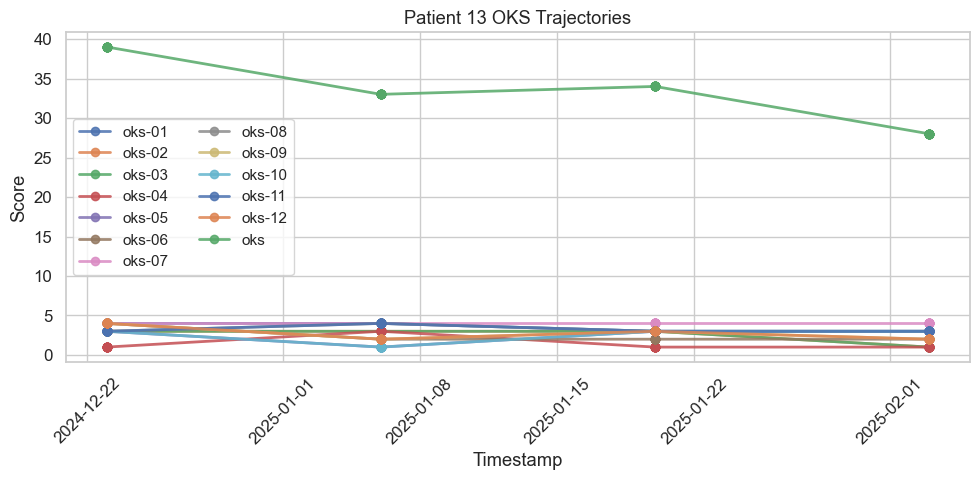


Patient 14: 14 rows = 56


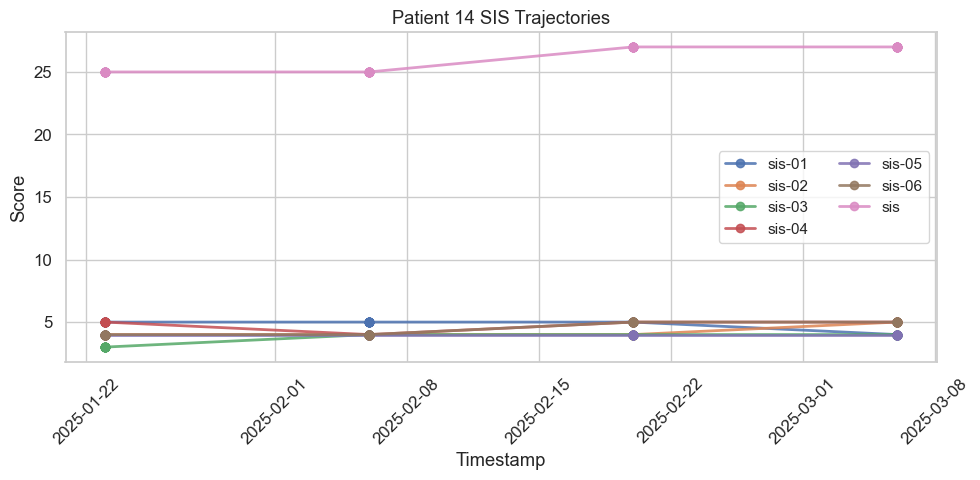

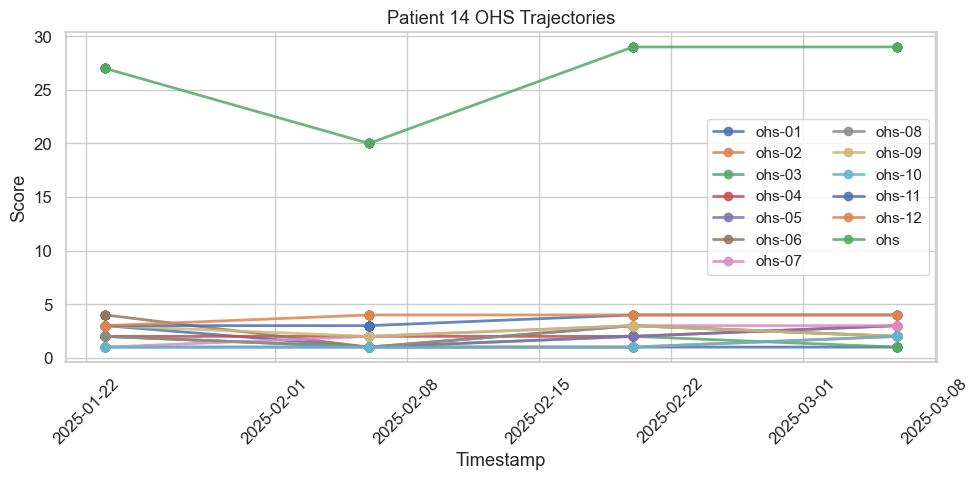

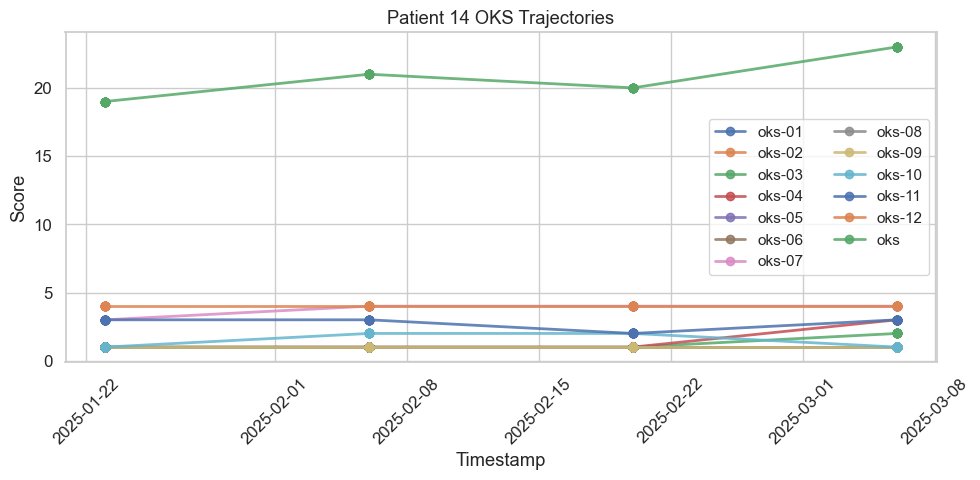


Patient 15: 15 rows = 56


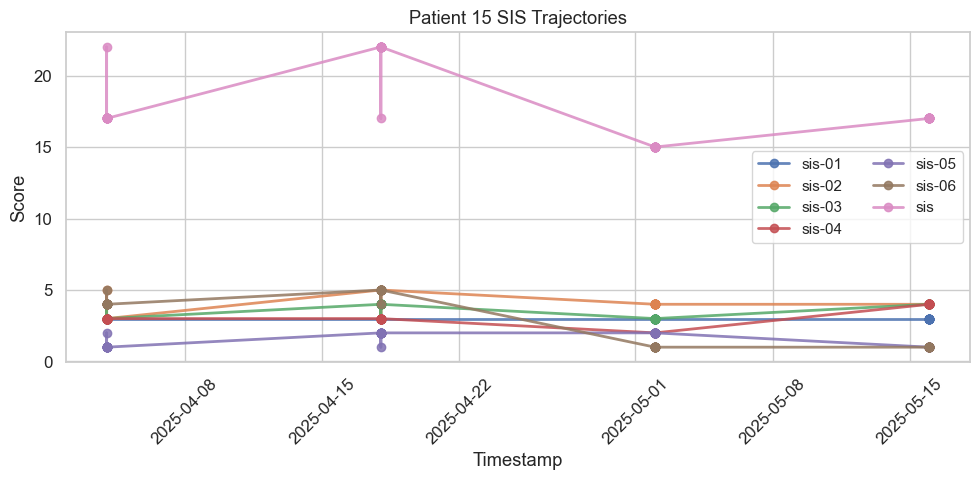

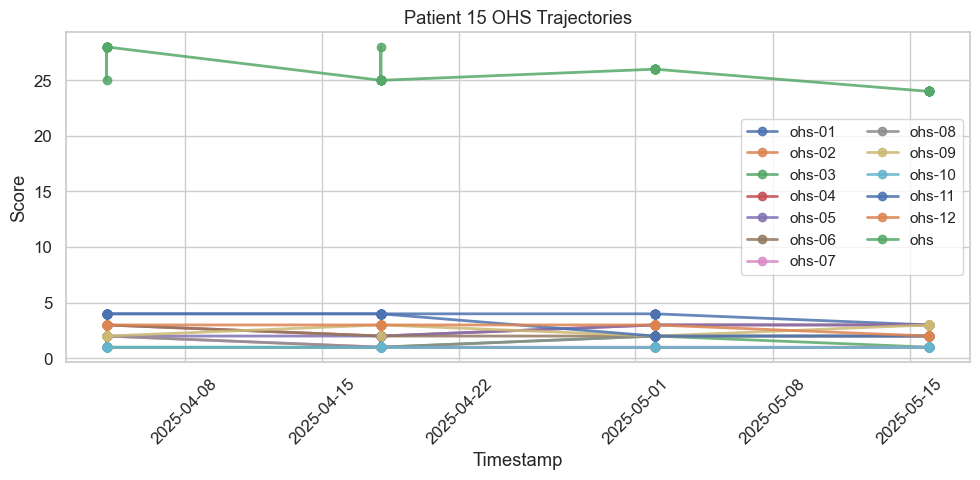

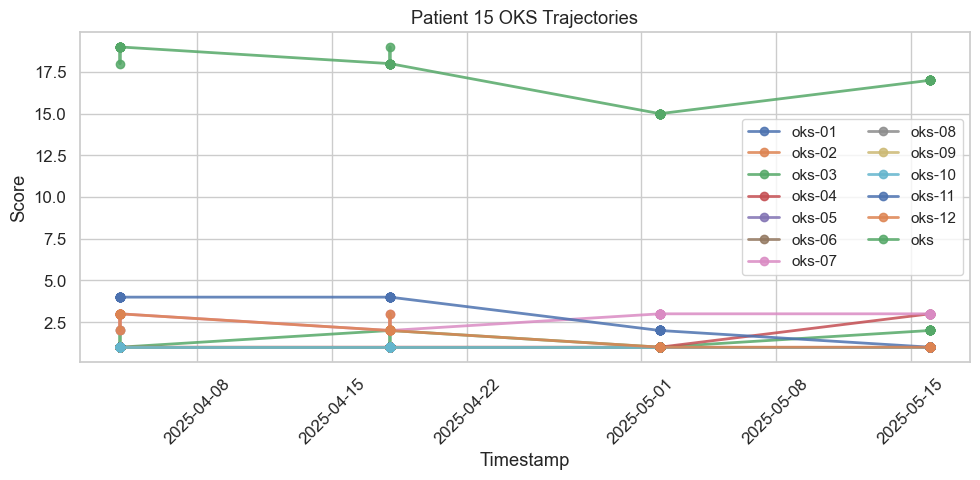


Patient 16: 16 rows = 56


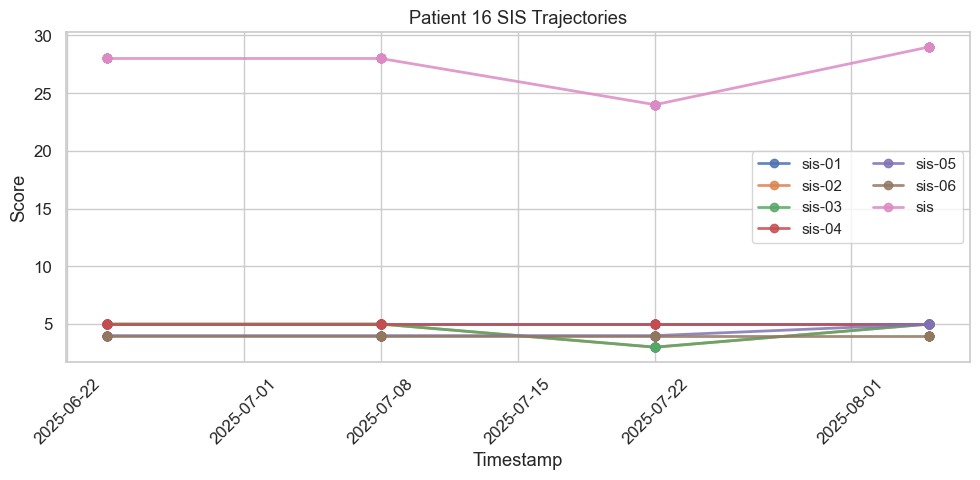

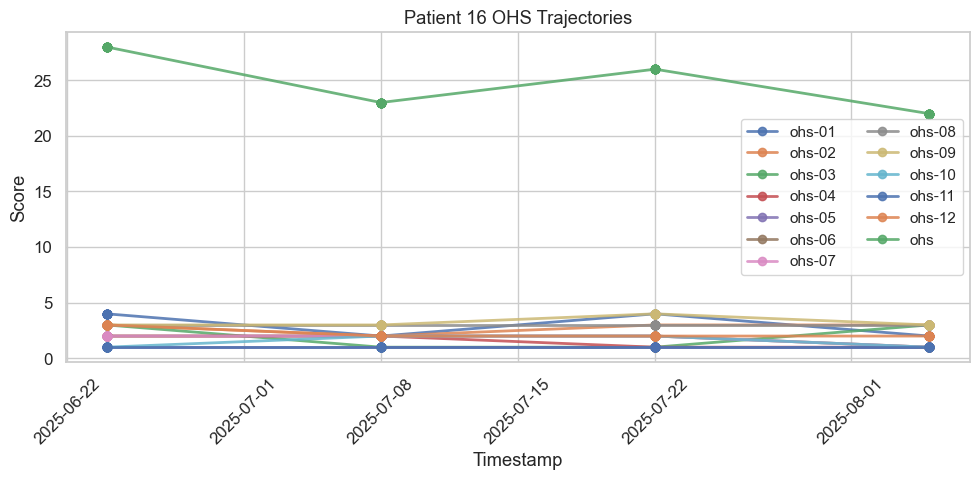

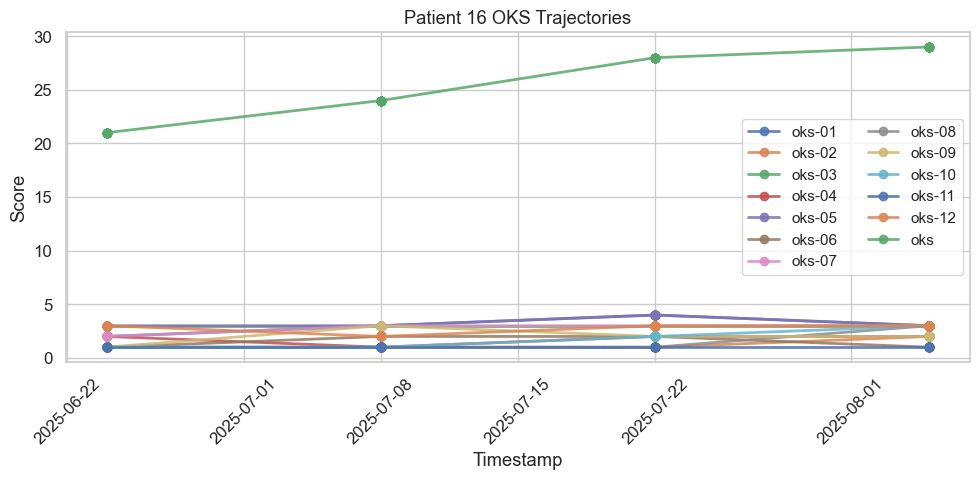


Patient 17: 17 rows = 56


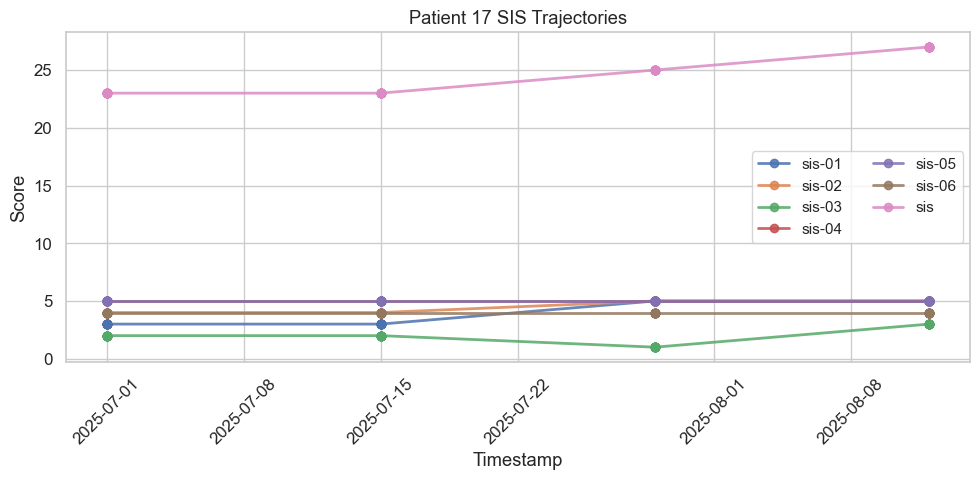

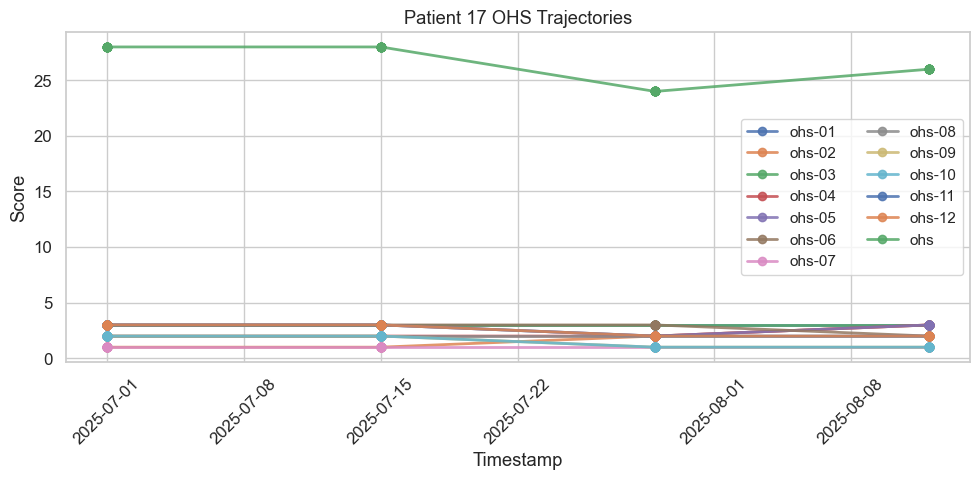

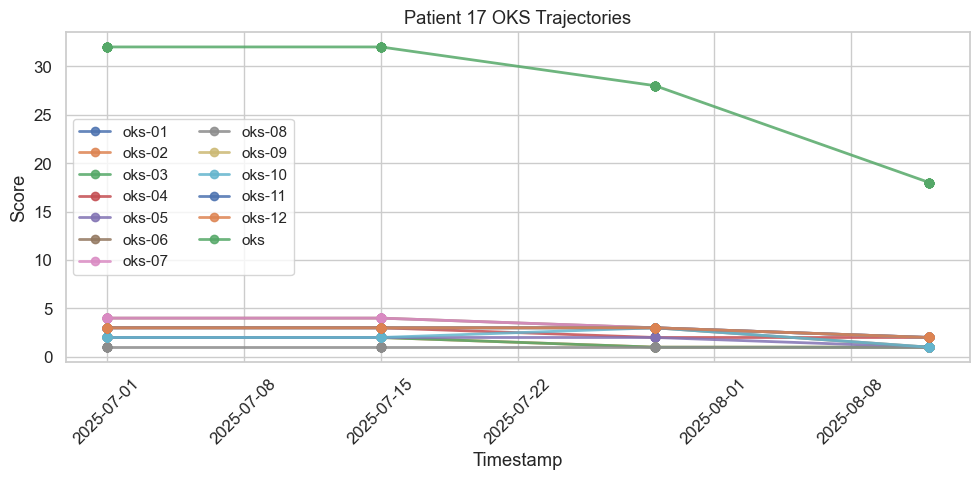


Patient 18: 18 rows = 56


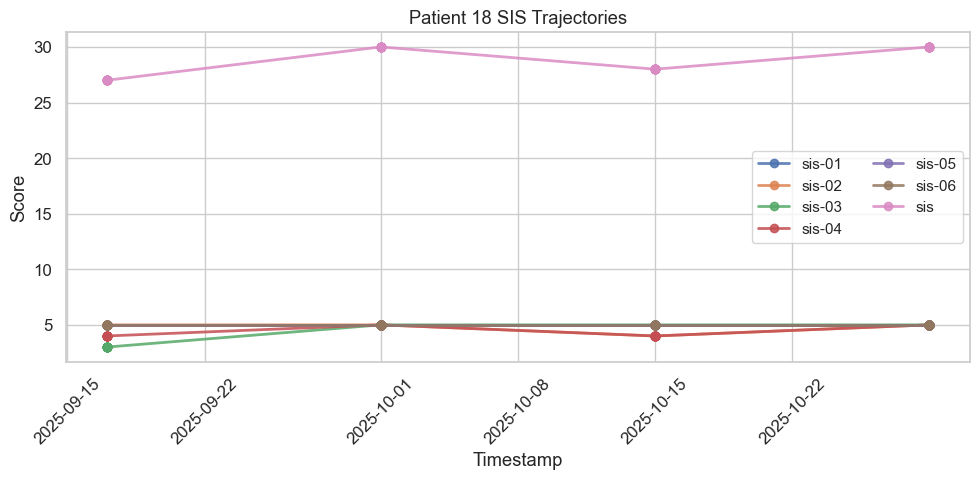

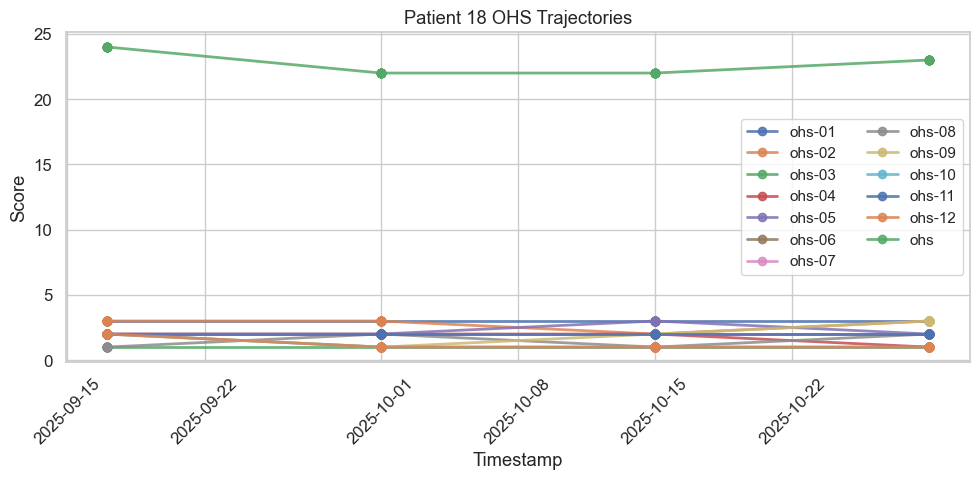

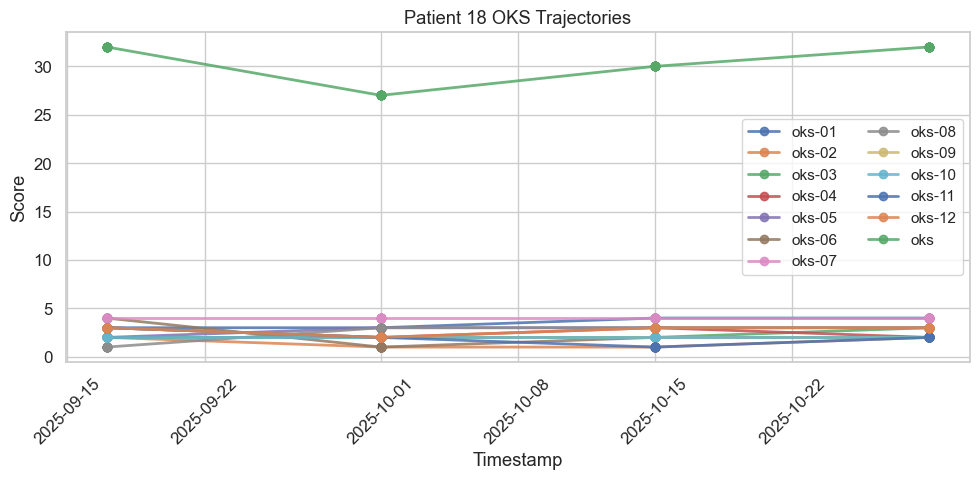

In [16]:
# Convert clinical timestamp to datetime for plotting
features["timestamp"] = pd.to_datetime(features["clinical-timestamp"])

score_groups = {
    "SIS": [f"sis-{i:02d}" for i in range(1, 7)] + ["sis"],
    "OHS": [f"ohs-{i:02d}" for i in range(1, 13)] + ["ohs"],
    "OKS": [f"oks-{i:02d}" for i in range(1, 13)] + ["oks"]
}

for participant_id, participant_df in features.groupby("participant"):
    participant_df = participant_df.sort_values("timestamp")
    print(f"\nPatient {participant_id}: {participant_df['participant'].iloc[0]} rows = {participant_df.shape[0]}")

    for score_name, score_cols in score_groups.items():
        plt.figure(figsize=(10, 5))
        for col in score_cols:
            if col in participant_df.columns:
                plt.plot(
                    participant_df["timestamp"],
                    participant_df[col],
                    marker="o",
                    label=col,
                    linewidth=2,
                    alpha=0.85
                )

        plt.title(f"Patient {participant_id} {score_name} Trajectories")
        plt.xlabel("Timestamp")
        plt.ylabel("Score")
        plt.xticks(rotation=45)
        plt.legend(loc="best", fontsize="small", ncol=2)
        plt.tight_layout()
        plt.show()


## Patient-level Acceleration Feature Trends
Plot patient-specific acceleration feature trajectories across clinical timestamps using two graphs per patient.


Patient 1: 56 rows


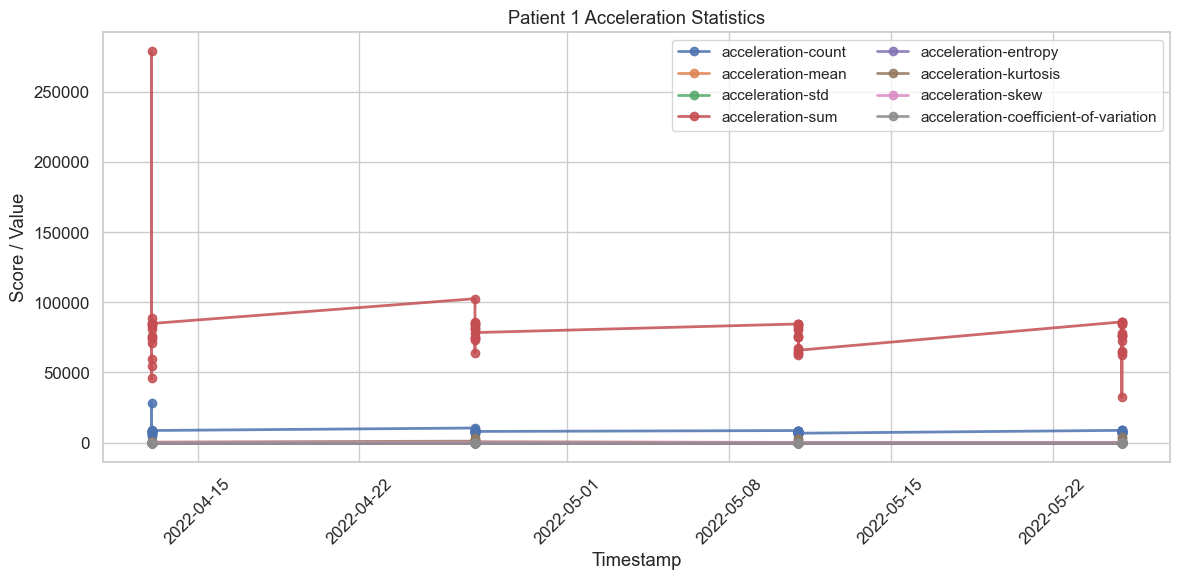

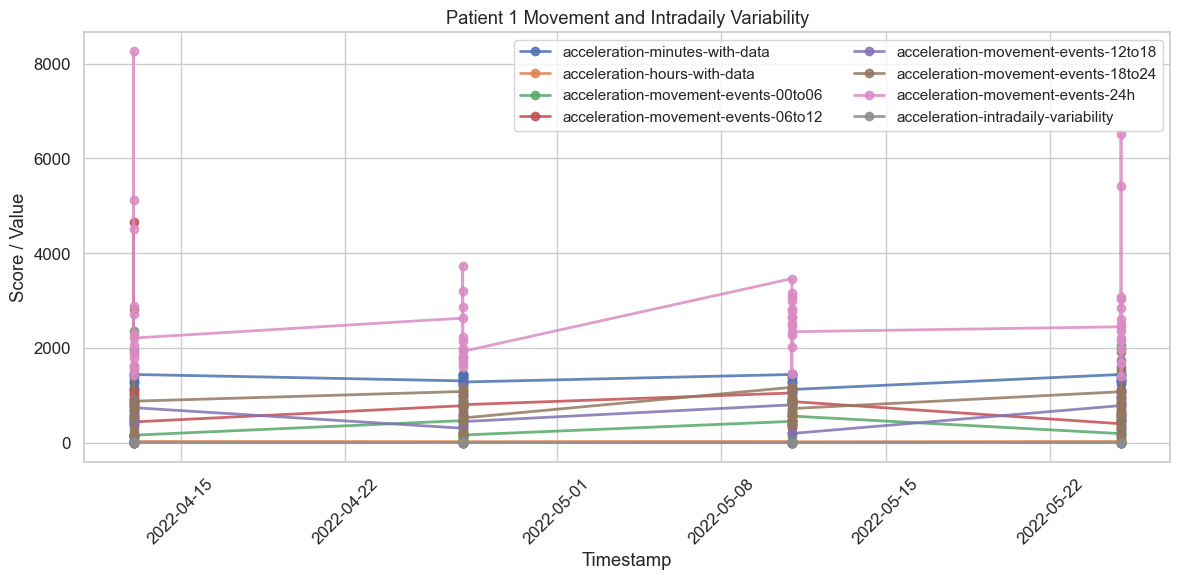


Patient 2: 56 rows


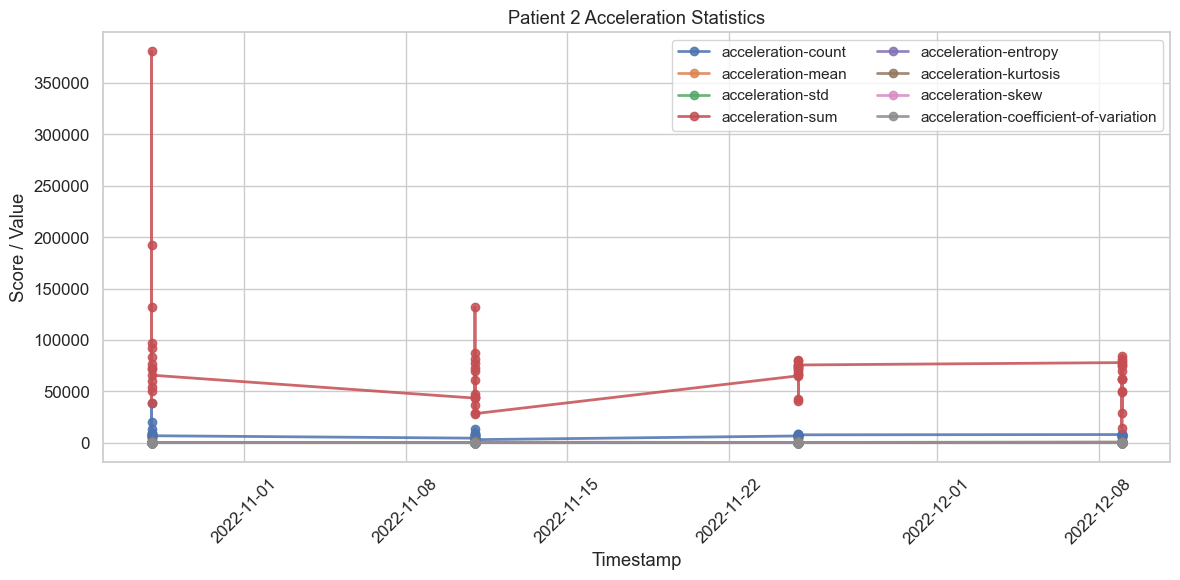

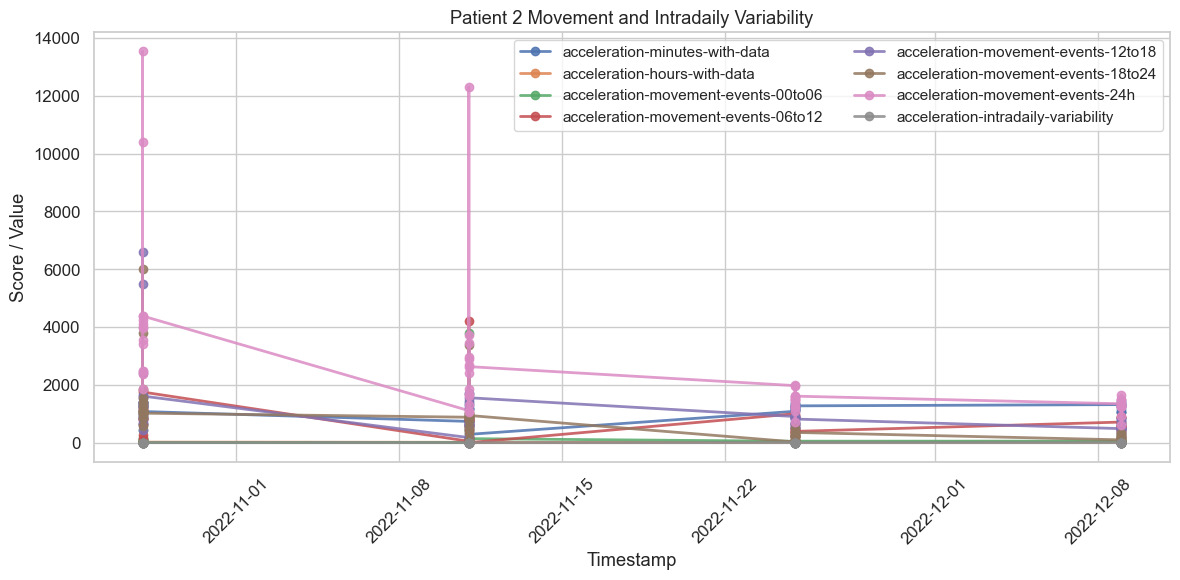


Patient 3: 56 rows


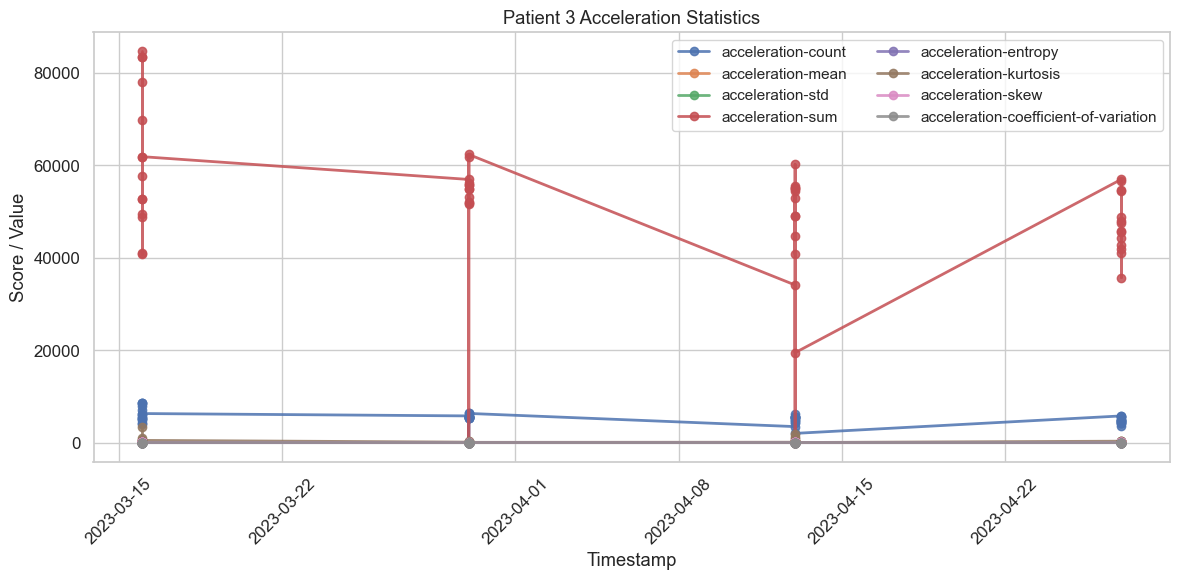

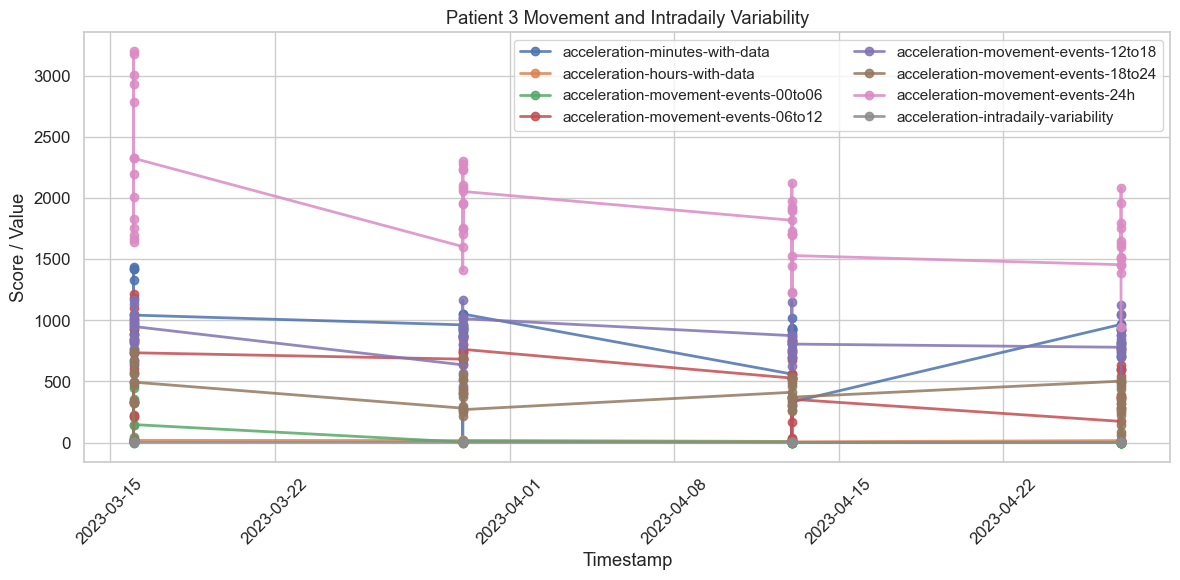


Patient 4: 56 rows


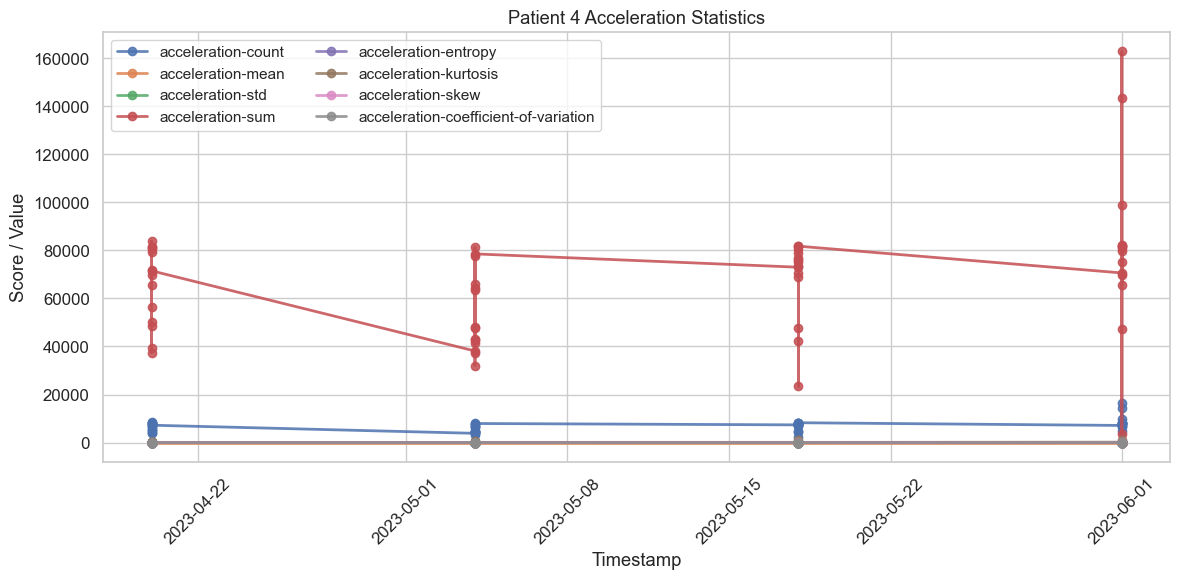

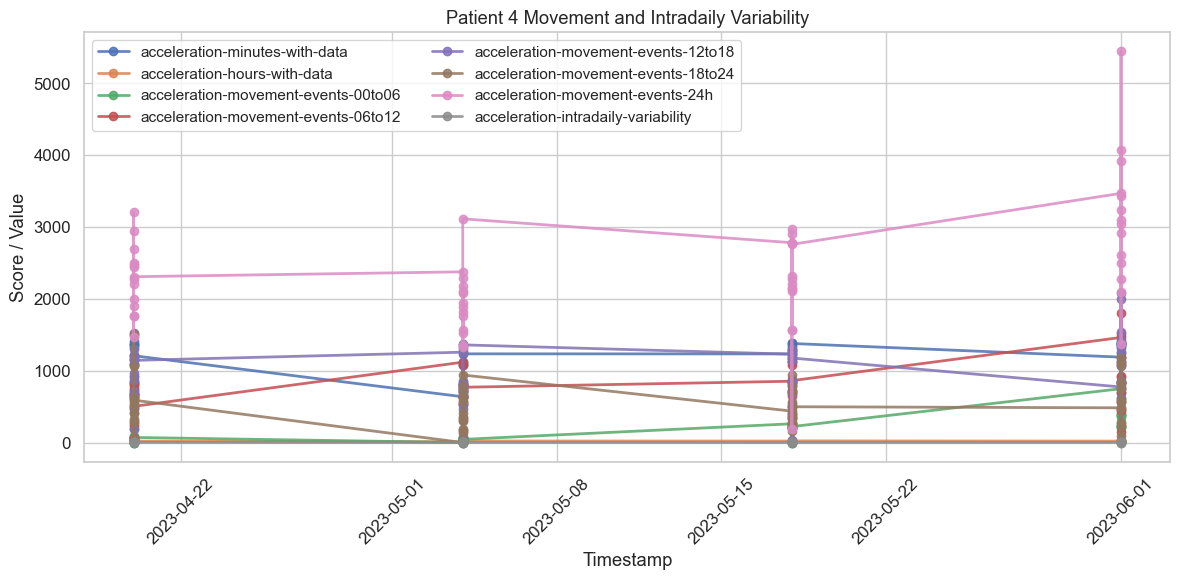


Patient 5: 56 rows


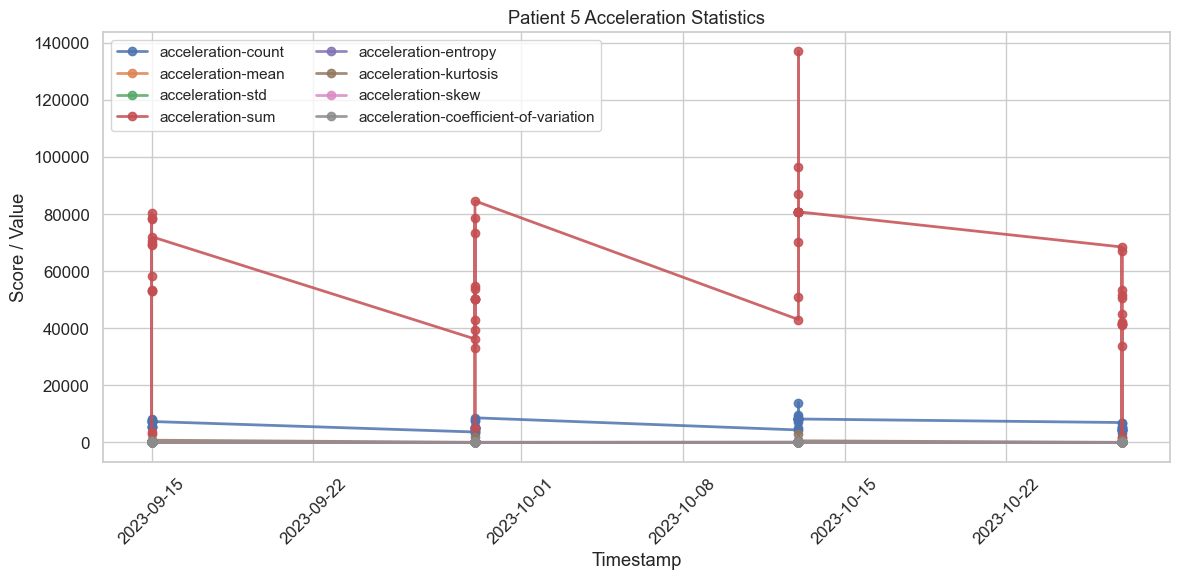

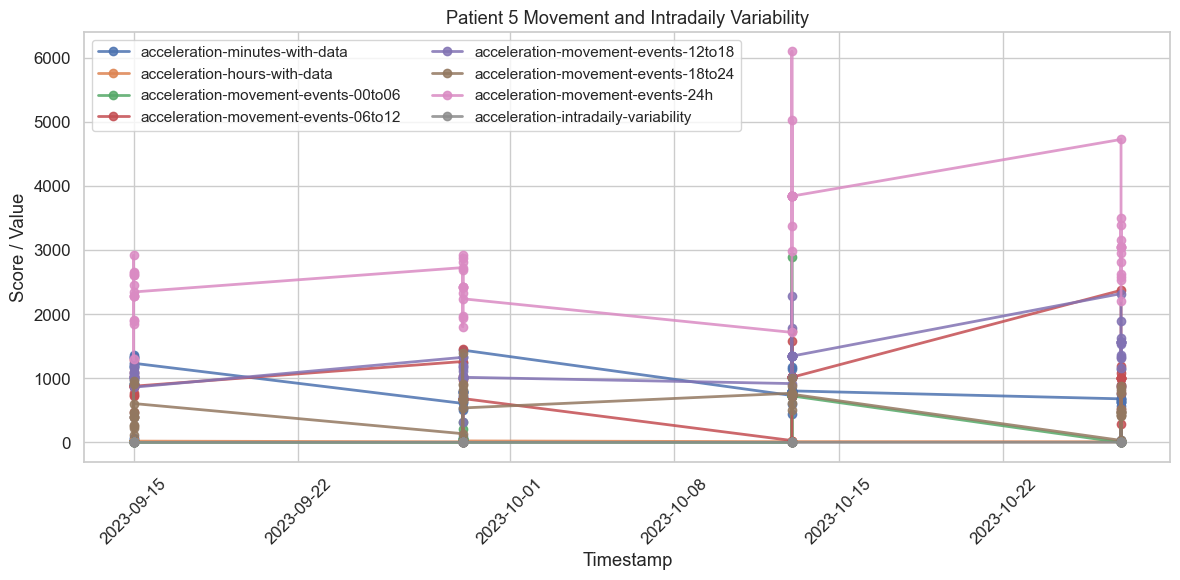


Patient 6: 56 rows


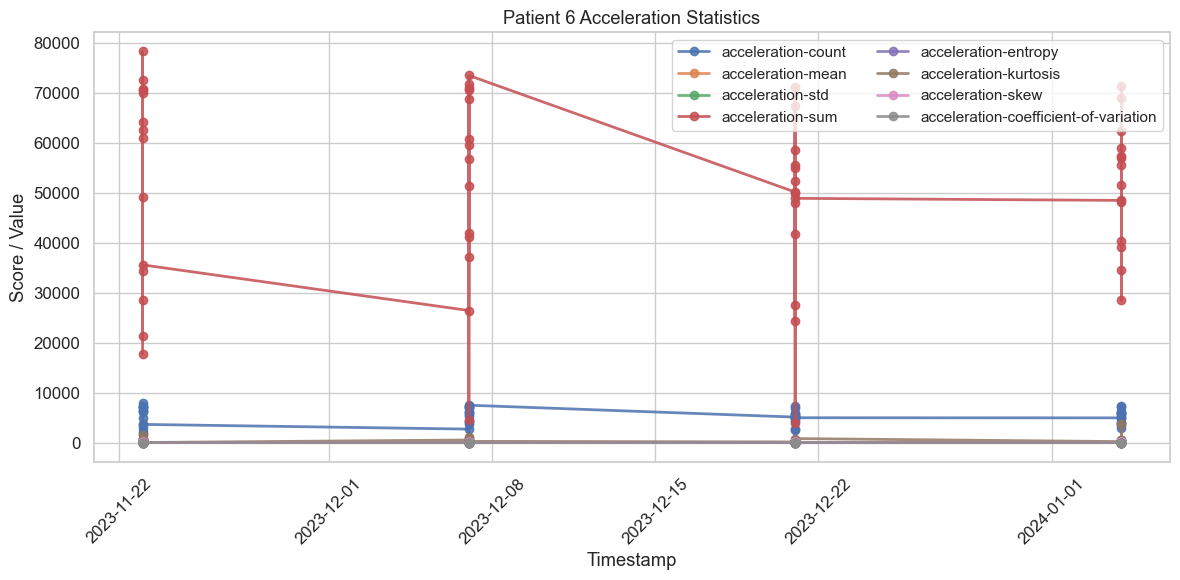

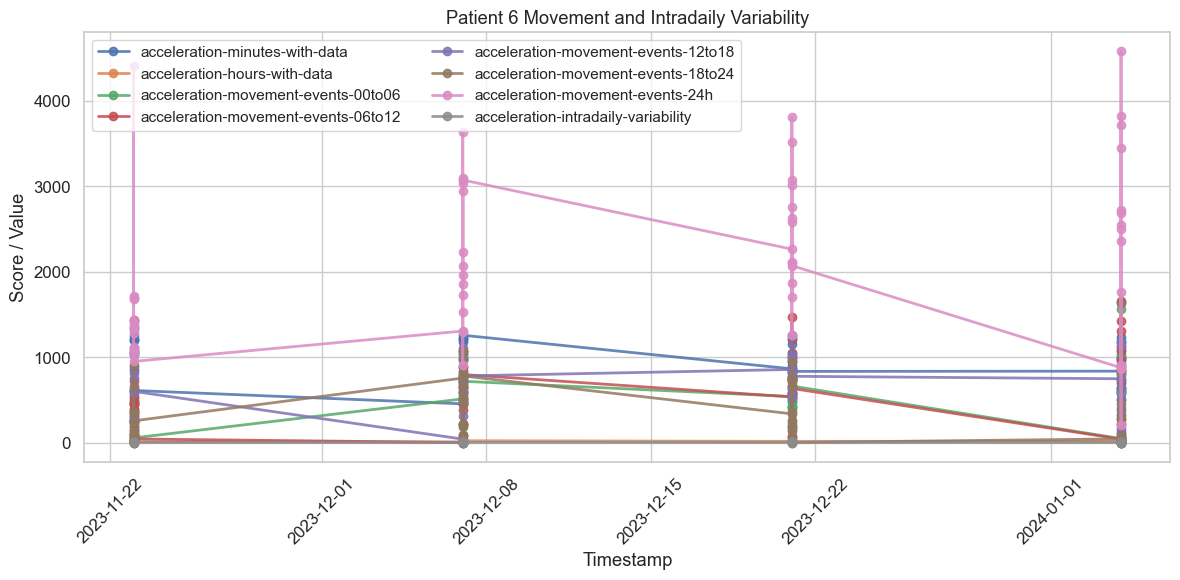


Patient 7: 56 rows


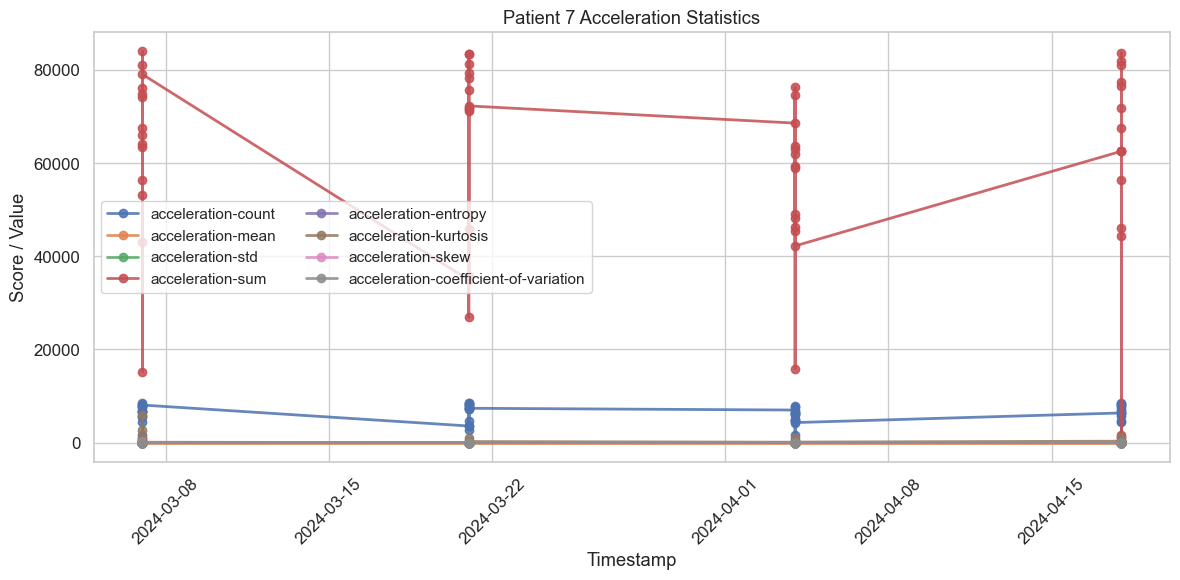

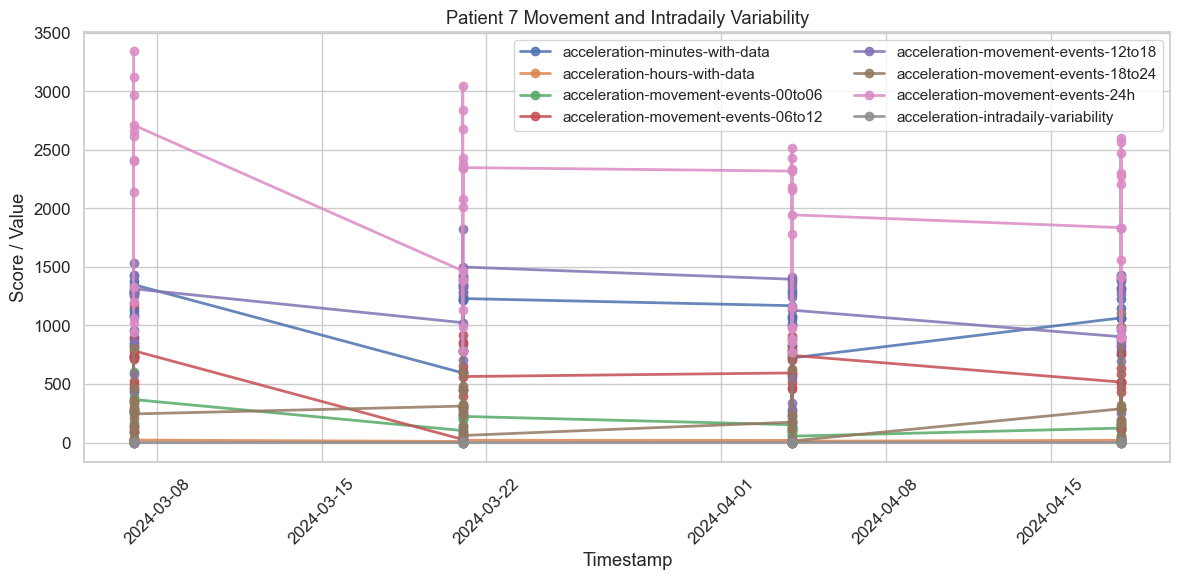


Patient 8: 56 rows


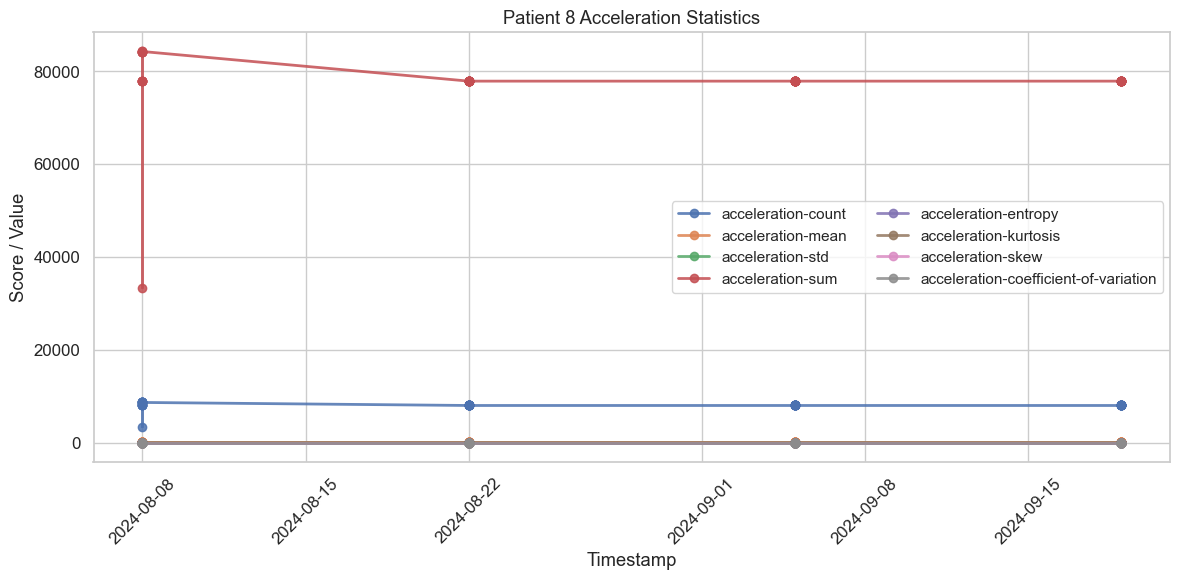

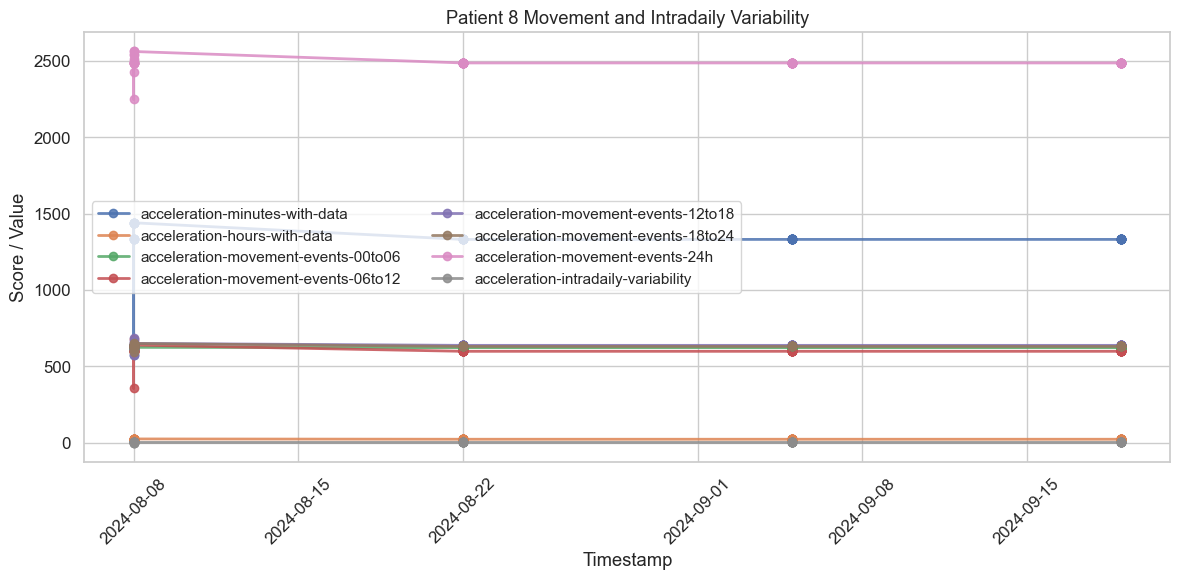


Patient 9: 56 rows


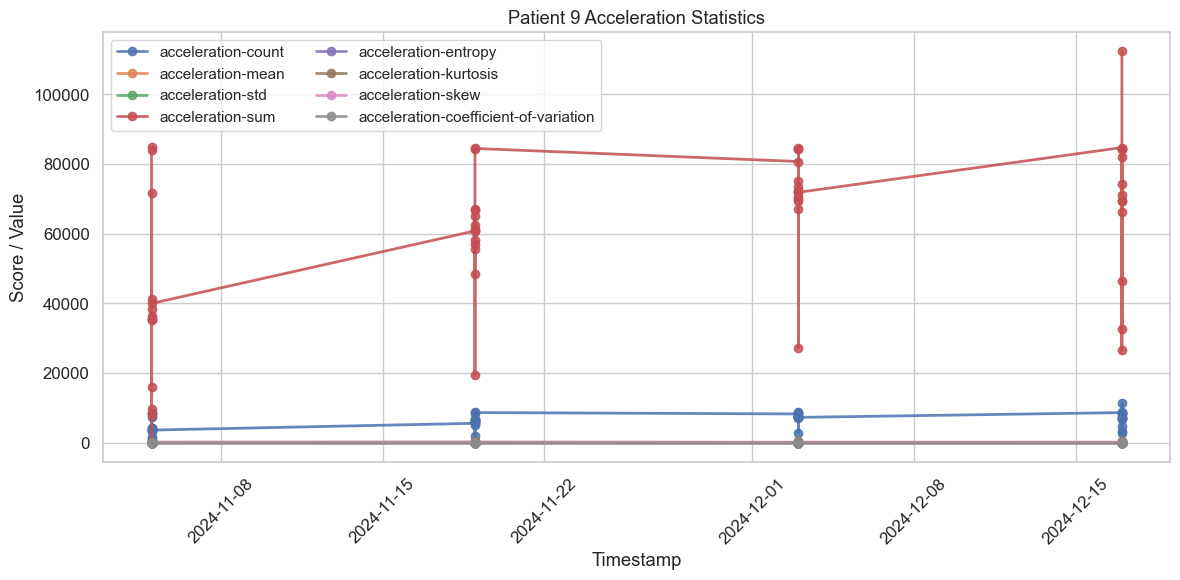

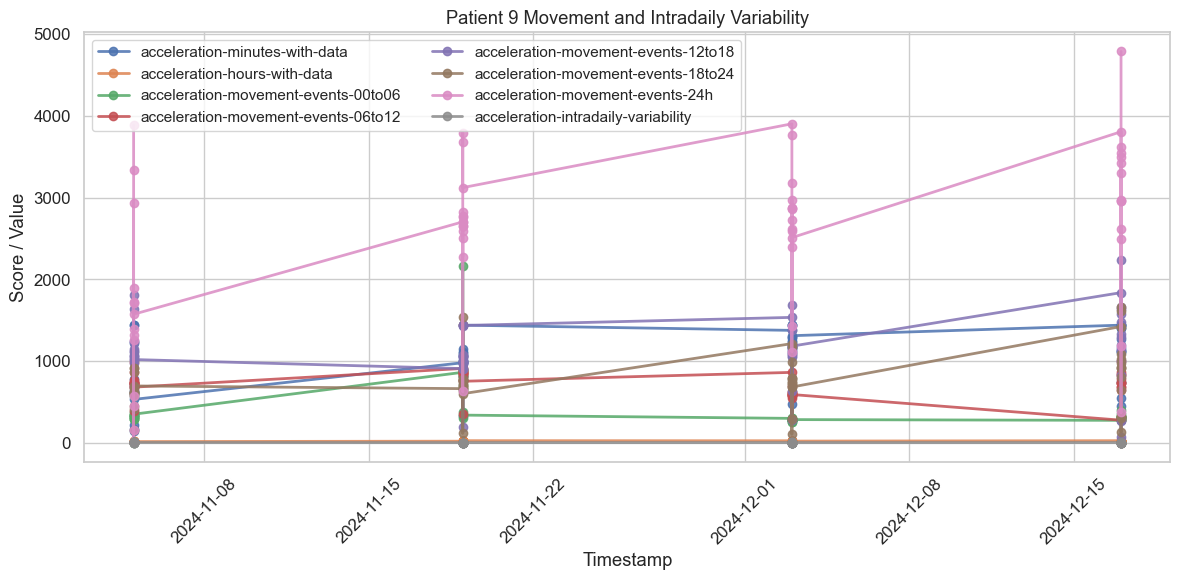


Patient 10: 56 rows


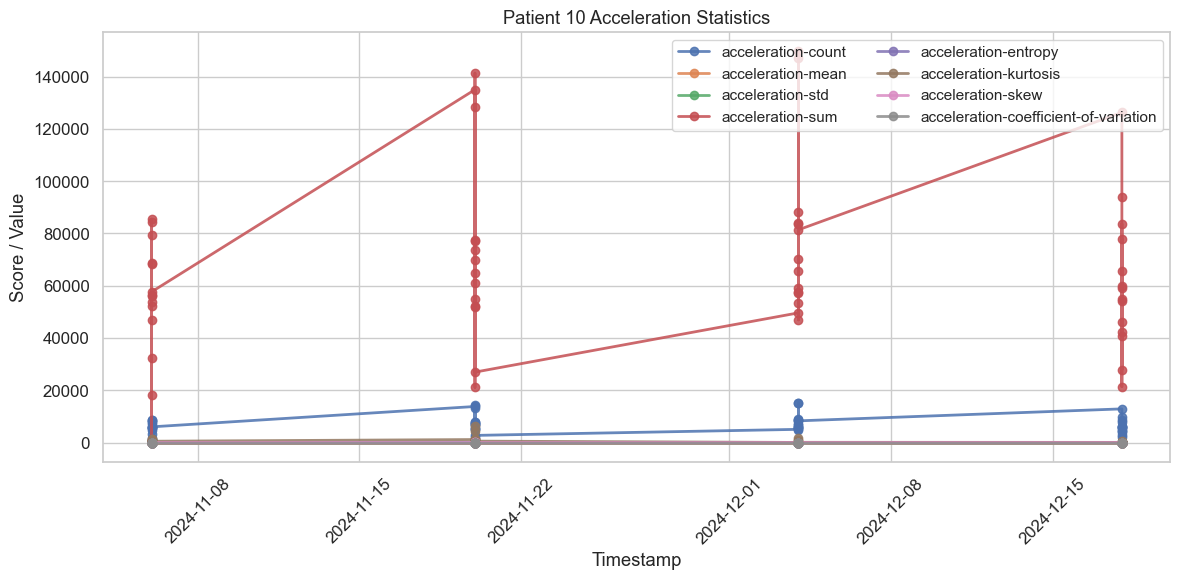

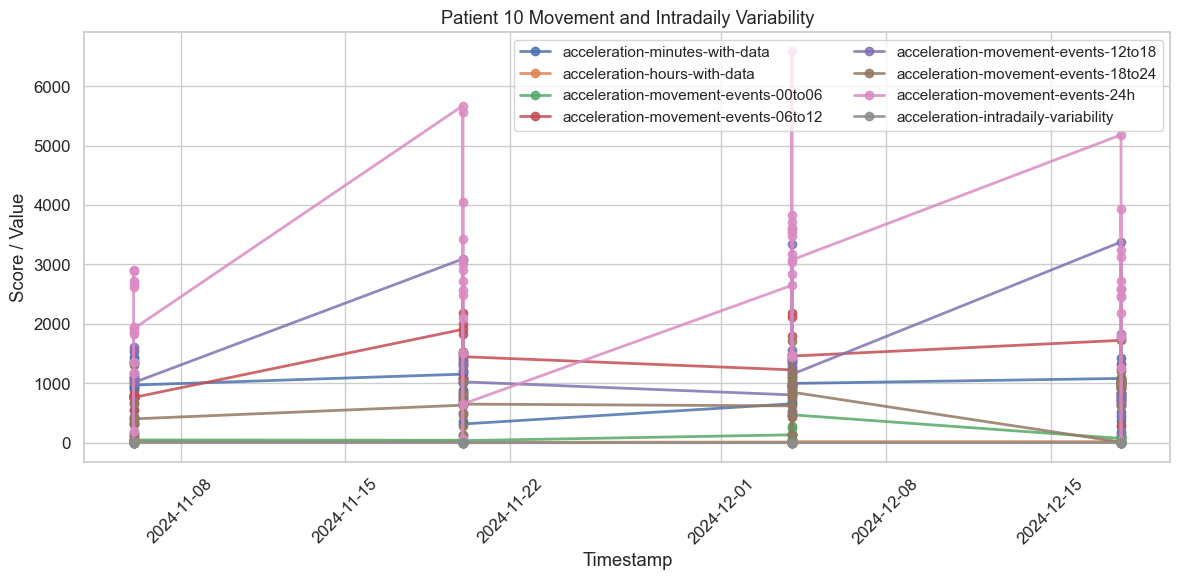


Patient 11: 56 rows


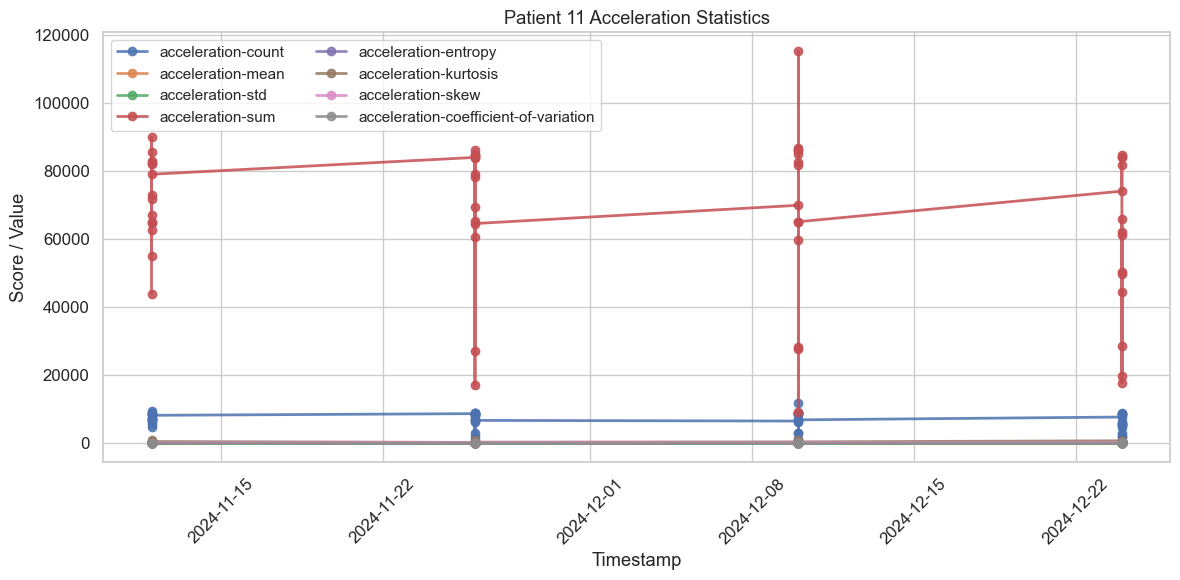

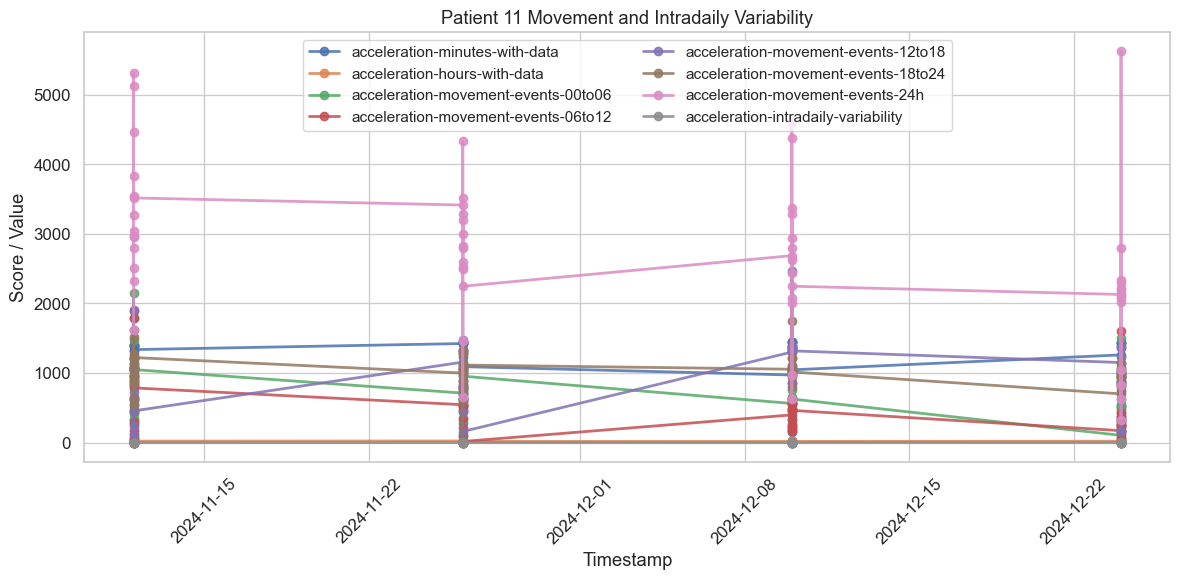


Patient 12: 56 rows


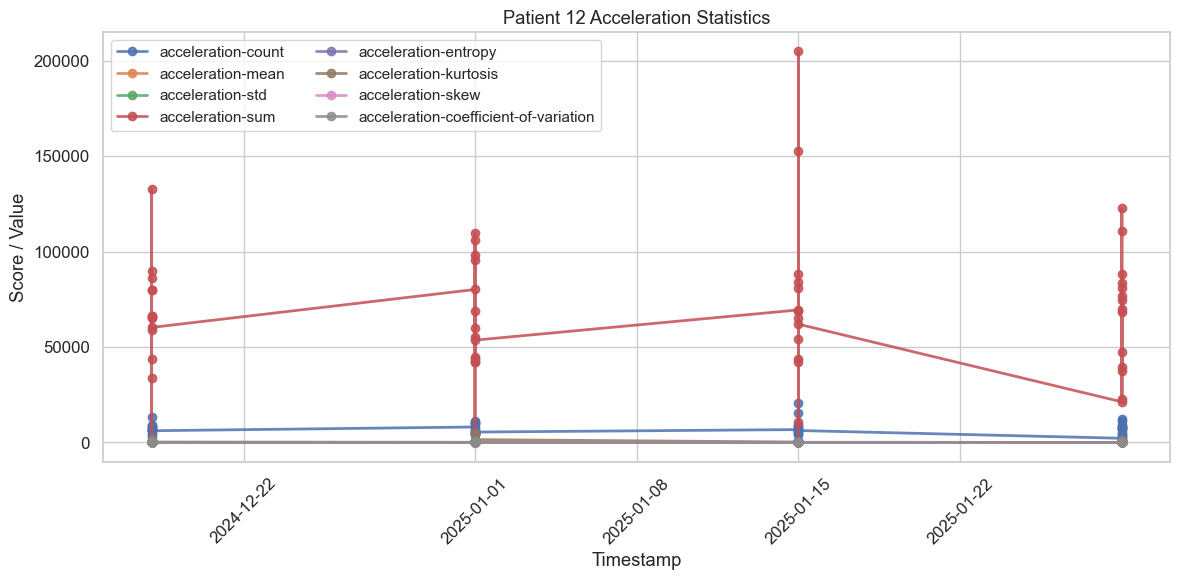

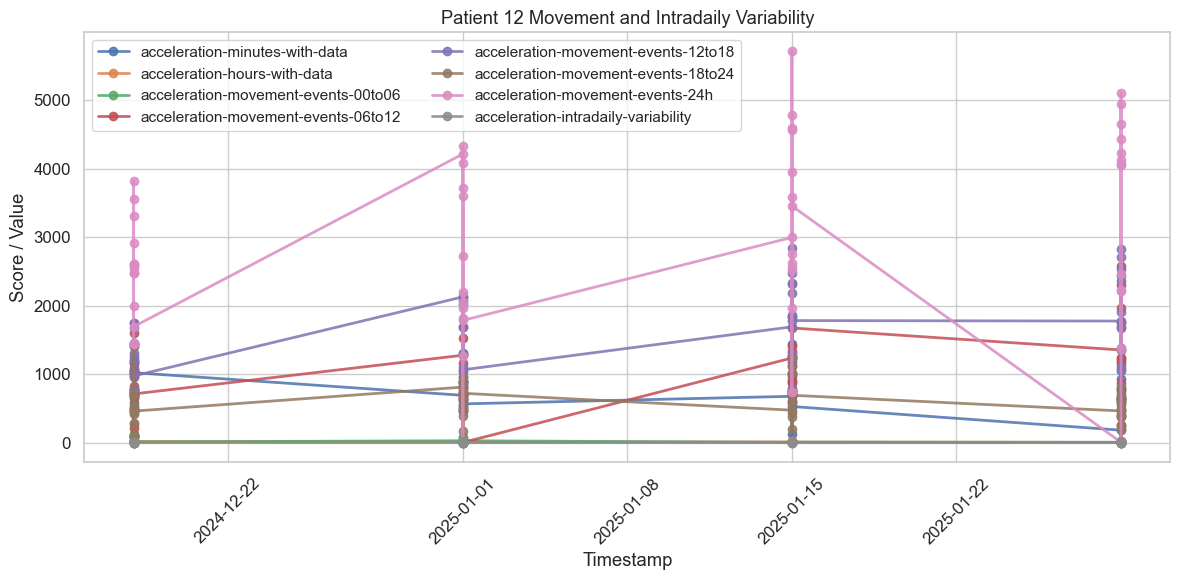


Patient 13: 56 rows


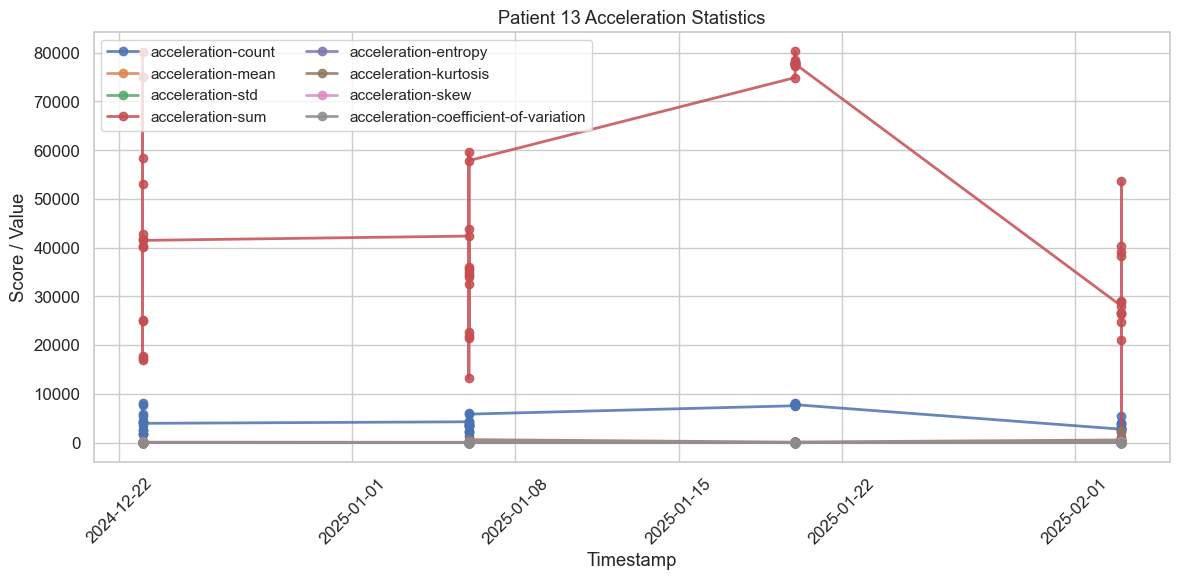

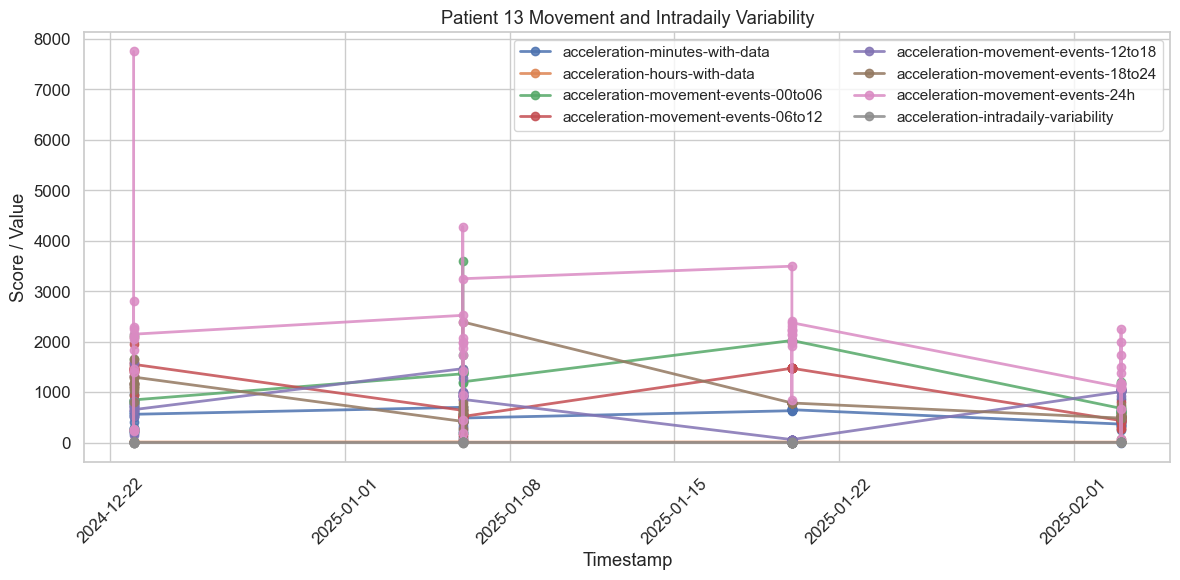


Patient 14: 56 rows


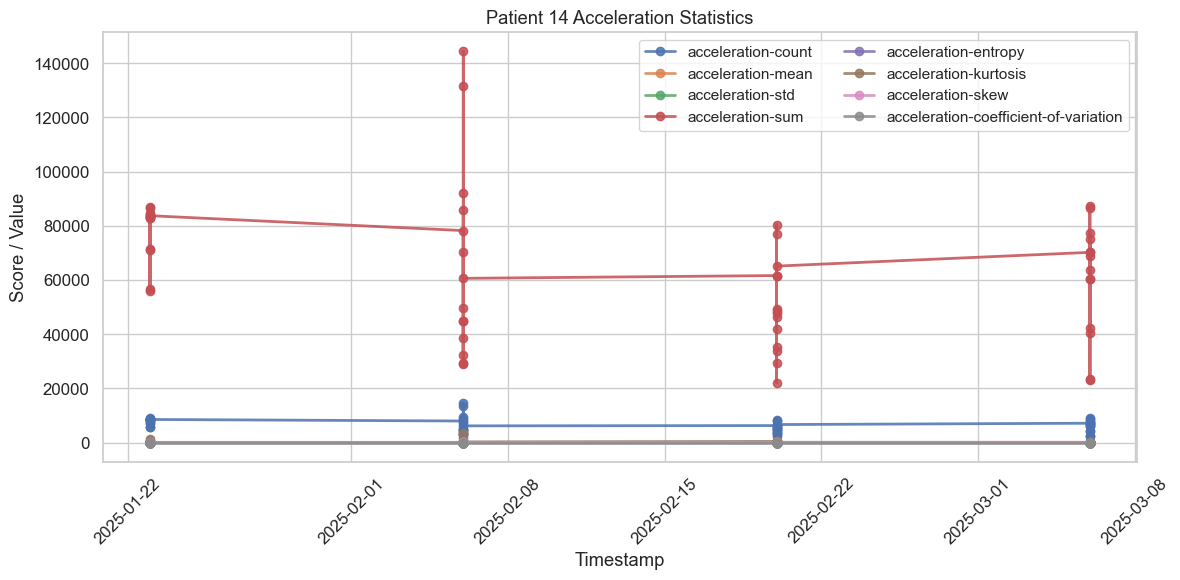

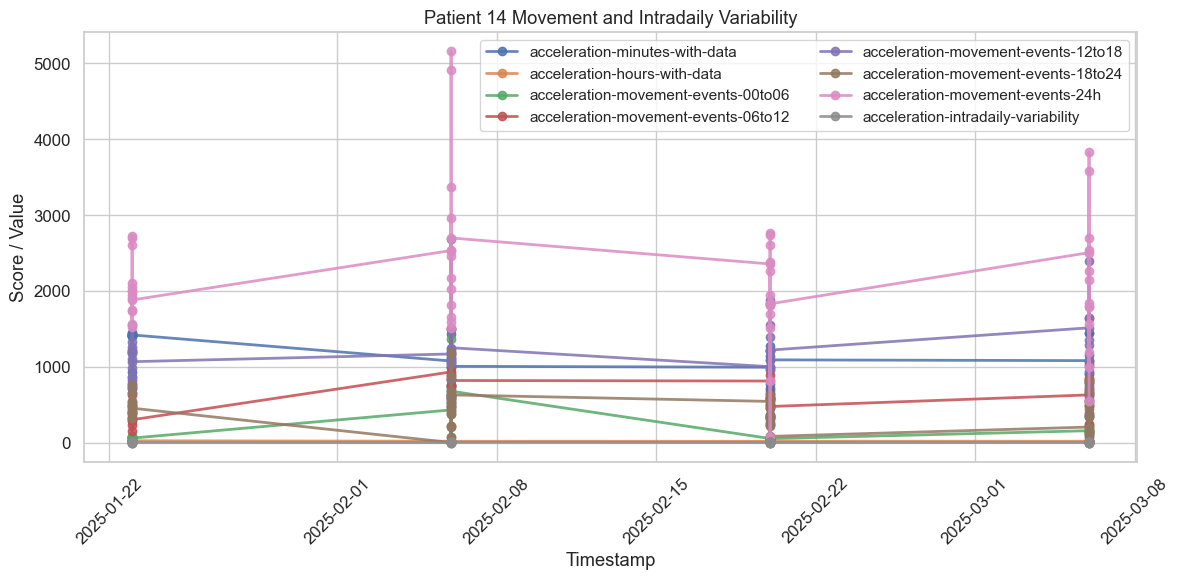


Patient 15: 56 rows


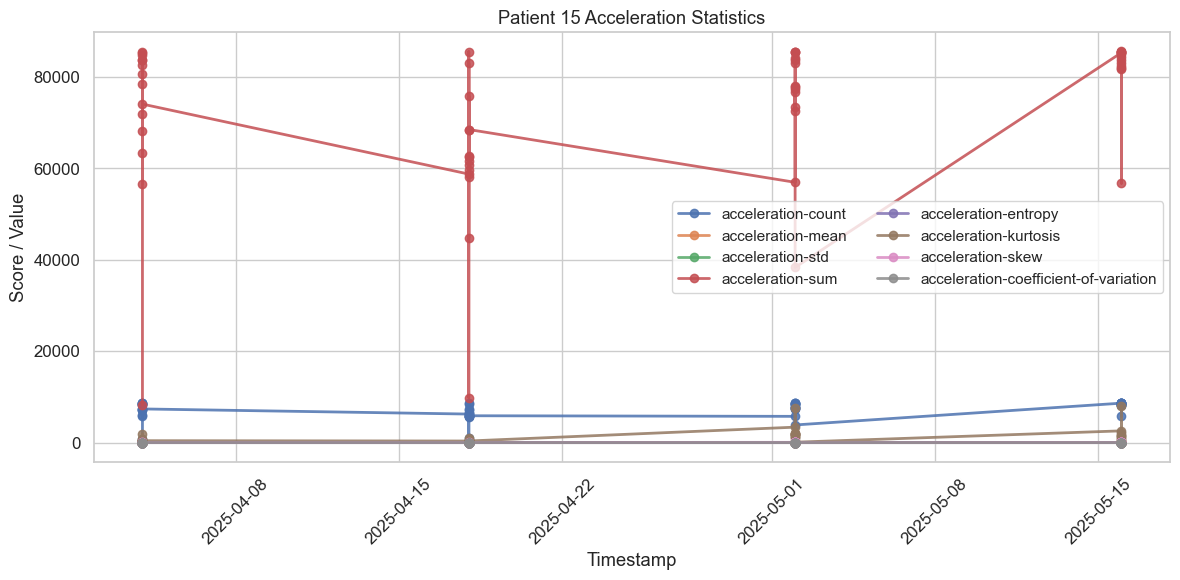

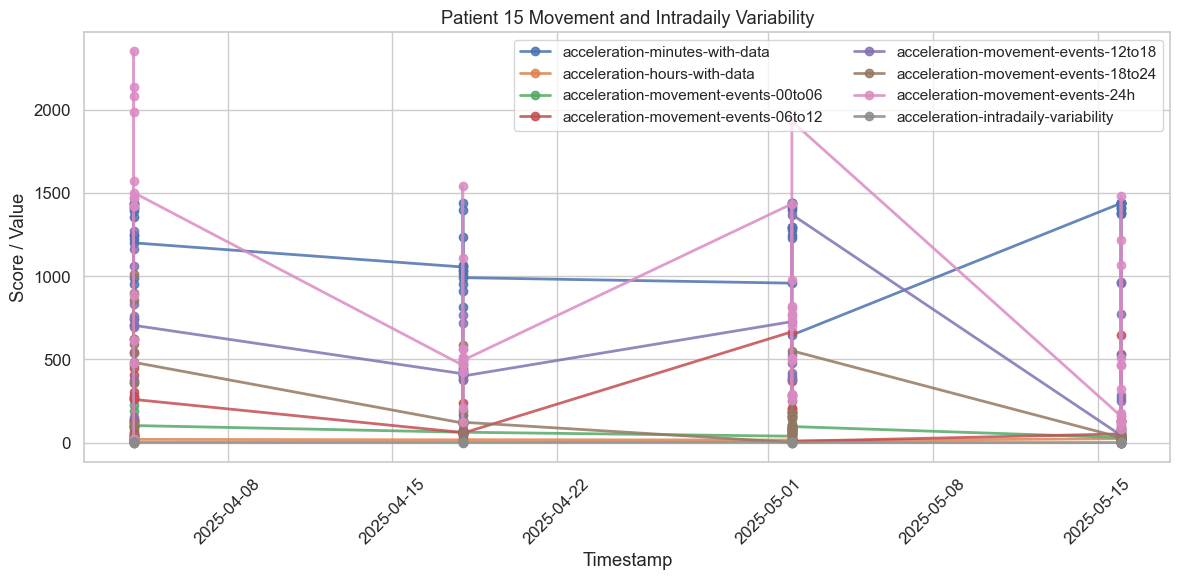


Patient 16: 56 rows


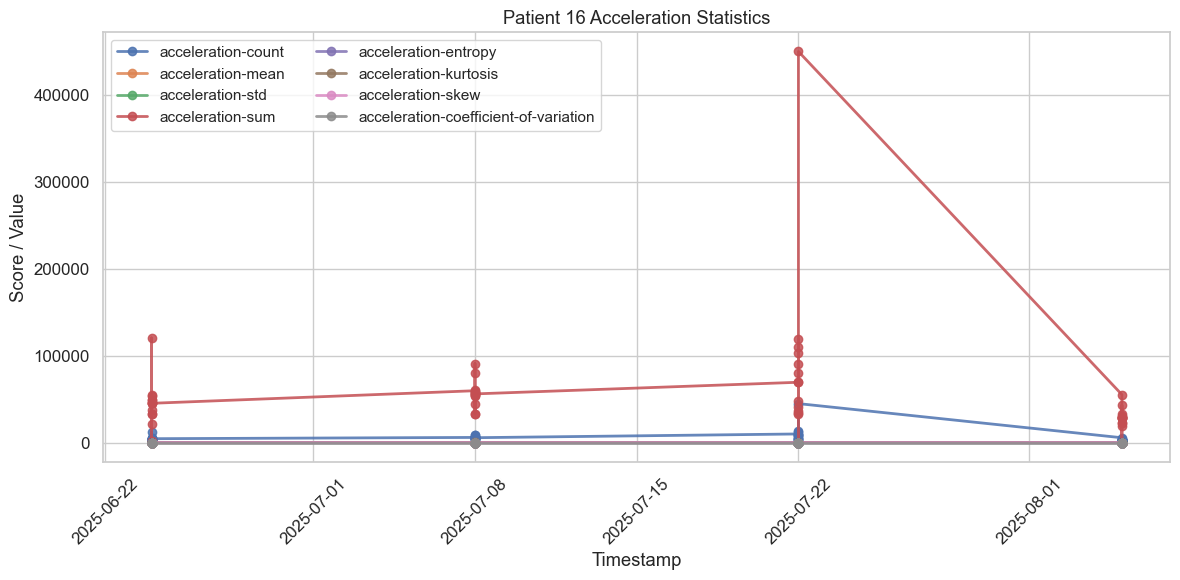

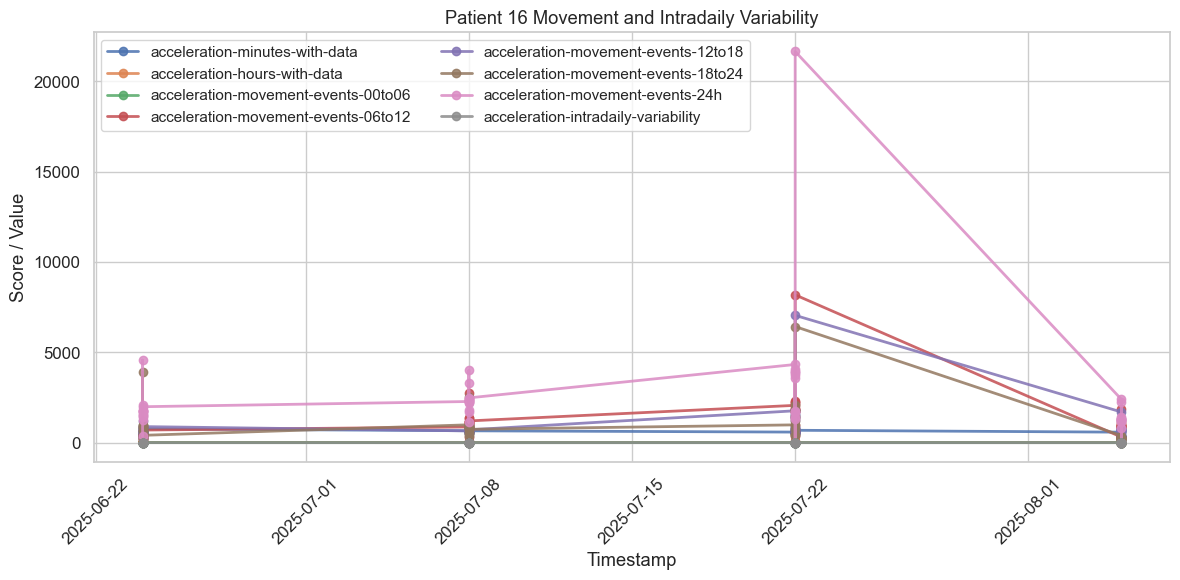


Patient 17: 56 rows


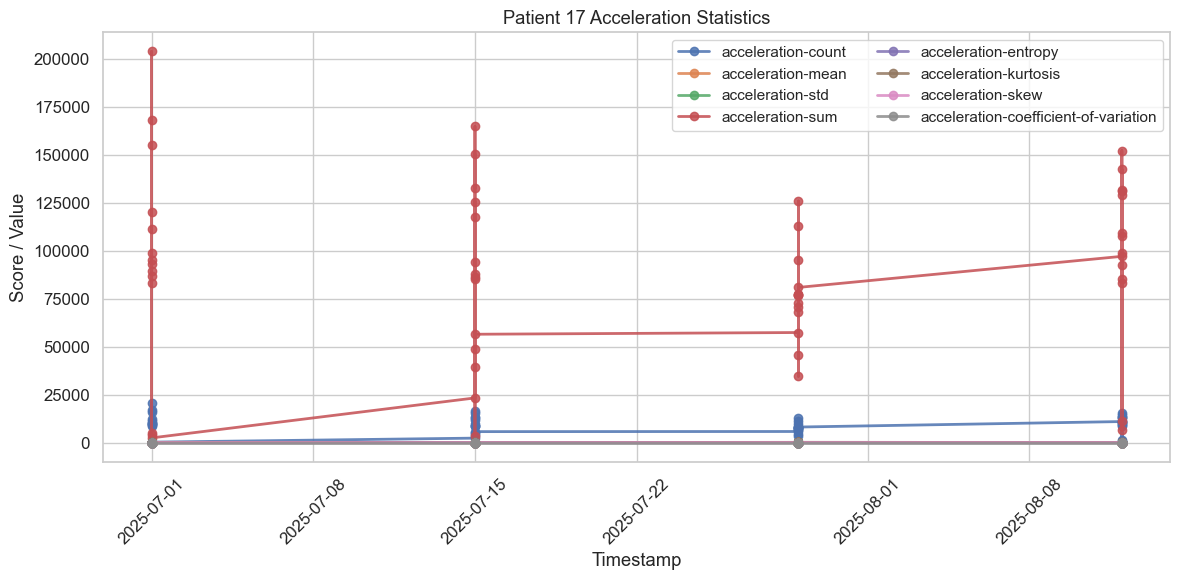

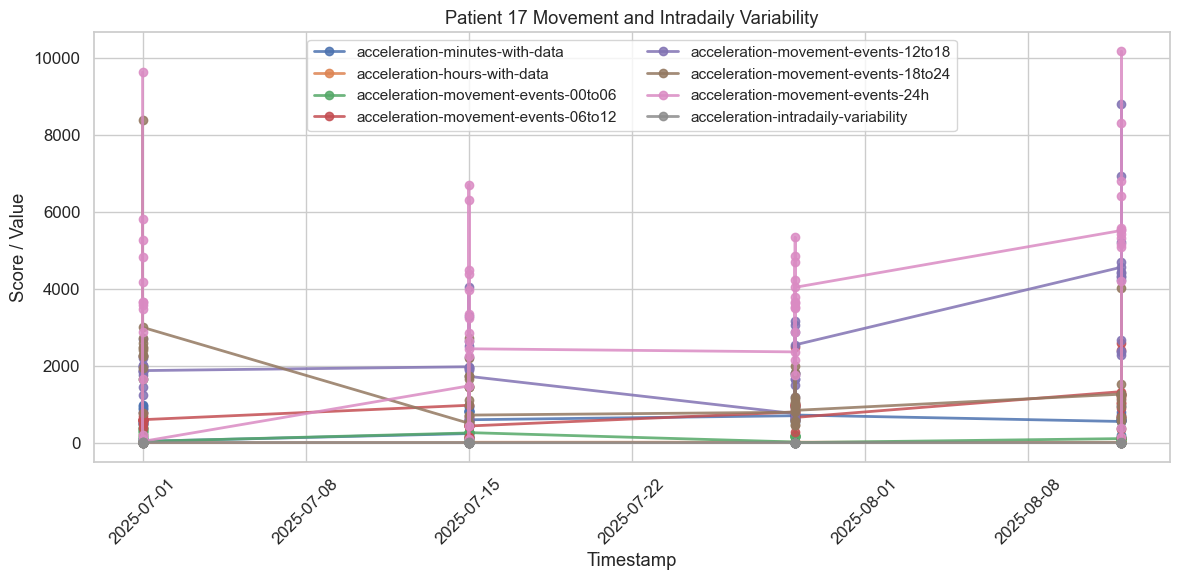


Patient 18: 56 rows


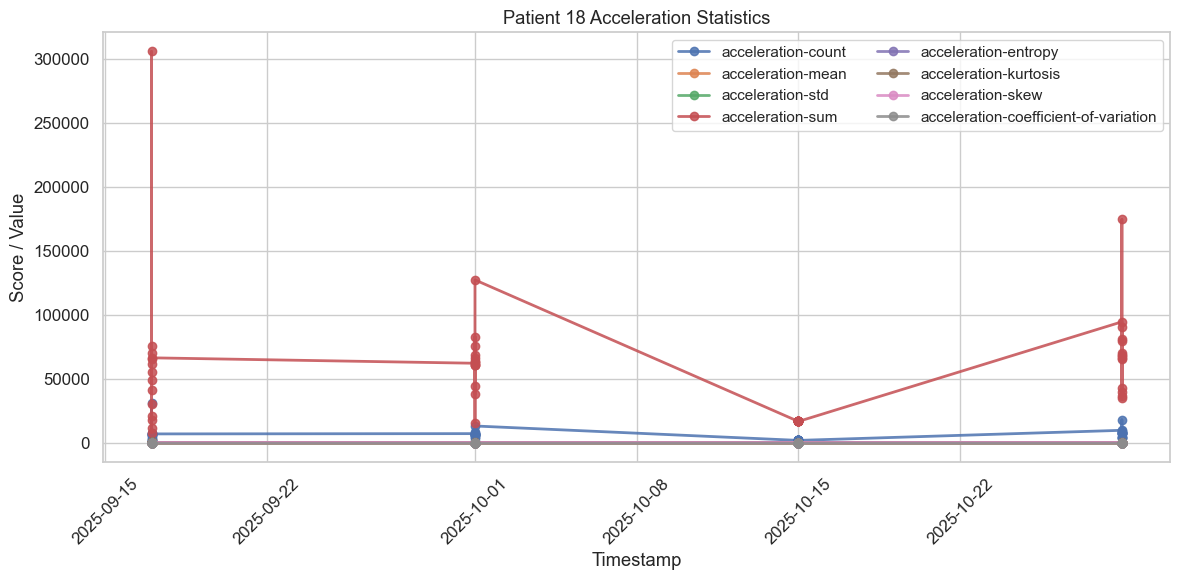

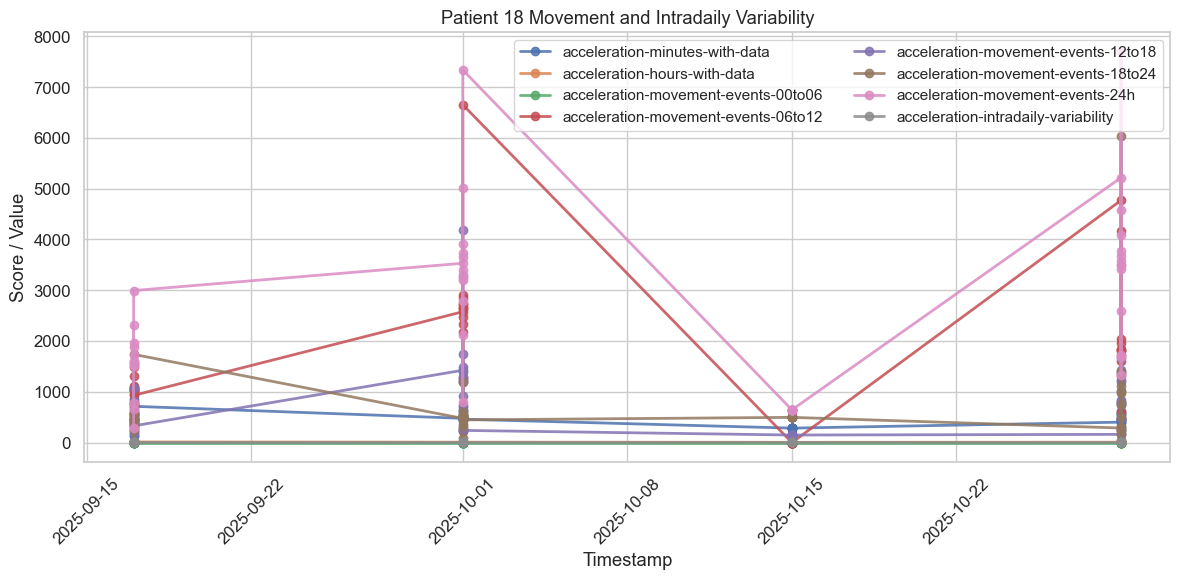

In [17]:
# Acceleration feature plot groups
acceleration_group = [
    "acceleration-count",
    "acceleration-mean",
    "acceleration-std",
    "acceleration-sum",
    "acceleration-entropy",
    "acceleration-kurtosis",
    "acceleration-skew",
    "acceleration-coefficient-of-variation"
]

movement_group = [
    "acceleration-minutes-with-data",
    "acceleration-hours-with-data",
    "acceleration-movement-events-00to06",
    "acceleration-movement-events-06to12",
    "acceleration-movement-events-12to18",
    "acceleration-movement-events-18to24",
    "acceleration-movement-events-24h",
    "acceleration-intradaily-variability"
]

for participant_id, participant_df in features.groupby("participant"):
    participant_df = participant_df.sort_values("timestamp")
    print(f"\nPatient {participant_id}: {participant_df.shape[0]} rows")

    # Plot acceleration statistics
    plt.figure(figsize=(12, 6))
    for col in acceleration_group:
        if col in participant_df.columns:
            plt.plot(
                participant_df["timestamp"],
                participant_df[col],
                marker="o",
                label=col,
                linewidth=2,
                alpha=0.85
            )
    plt.title(f"Patient {participant_id} Acceleration Statistics")
    plt.xlabel("Timestamp")
    plt.ylabel("Score / Value")
    plt.xticks(rotation=45)
    plt.legend(loc="best", fontsize="small", ncol=2)
    plt.tight_layout()
    plt.show()

    # Plot movement and intradaily metrics
    plt.figure(figsize=(12, 6))
    for col in movement_group:
        if col in participant_df.columns:
            plt.plot(
                participant_df["timestamp"],
                participant_df[col],
                marker="o",
                label=col,
                linewidth=2,
                alpha=0.85
            )
    plt.title(f"Patient {participant_id} Movement and Intradaily Variability")
    plt.xlabel("Timestamp")
    plt.ylabel("Score / Value")
    plt.xticks(rotation=45)
    plt.legend(loc="best", fontsize="small", ncol=2)
    plt.tight_layout()
    plt.show()
